In [1]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")
    
import random

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *
from antipode.antipode_mixins import AntipodeTrainingMixin, AntipodeSaveLoadMixin

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA TITAN X (Pascal)


In [2]:
# device = 'cpu'

In [3]:
def min_max(x):
    return x.min(),x.max()

In [4]:
class AntipodeTrainingMixin:
    '''
    Mixin class providing functions to actually run ANTIPODE.
    The naive model trains in 3 phases, first a nonhierarchical block phase to estimate cell type manifolds, then phase 2 learns parameters for a fixed discrete clustering on a fixed latent space for initialization (or supervised). Phase 3 makes all parameters learnable.
    You can also use supervised taxonomy by providing a clustering as a discrete obsm matrix and training only phase2 with freeze_encoder=False.
    '''
    
    def save_params_to_uns(self,prefix=''):
        pstore=param_store_to_numpy()
        pstore={n:pstore[n] for n in pstore.keys() if not re.search('encoder|classifier|be_nn|\$\$\$',n)}
        pstore={n:pstore[n] for n in pstore.keys() if not np.isnan(pstore[n]).any()}
        self.adata_manager.adata.uns[prefix+'param_store']=pstore

    def get_antipode_outputs(self,batch_size=2048,device='cuda'):
        if 'discov_onehot' not in self.adata_manager.adata.obsm.keys():
            self.adata_manager.adata.obs[self.discov_key]=self.adata_manager.adata.obs[self.discov_key].astype('category')
            self.adata_manager.adata.obsm['discov_onehot']=numpy_onehot(self.adata_manager.adata.obs[self.discov_key].cat.codes)
        self.adata_manager.register_new_fields([scvi.data.fields.ObsmField('discov_onehot','discov_onehot')])
    
        field_types={"s":np.float32,"discov_onehot":np.float32}
        dataloader=scvi.dataloaders.AnnDataLoader(self.adata_manager,batch_size=32,drop_last=False,shuffle=False,data_and_attributes=field_types)#supervised_field_types for supervised step 
        encoder_outs=batch_output_from_dataloader(dataloader,self.zl_encoder,batch_size=batch_size,device=device)
        encoder_outs[0]=self.z_transform(encoder_outs[0])
        encoder_out=[x.detach().cpu().numpy() for x in encoder_outs]
        classifier_outs=batch_torch_outputs([(encoder_outs[0])],self.classifier,batch_size=batch_size,device='cuda')
        classifier_out=[x.detach().cpu().numpy() for x in classifier_outs]
        return encoder_out,classifier_out

    def store_outputs(self,device='cuda',prefix=''):
        self.save_params_to_uns(prefix='')
        self.to('cpu')
        self.eval()
        antipode_outs=self.get_antipode_outputs(batch_size=2048,device=device)
        self.allDone()
        taxon=antipode_outs[1][0]
        self.adata_manager.adata.obsm[prefix+'X_antipode']=antipode_outs[0][0]
        for i in range(antipode_outs[1][1].shape[1]):
            self.adata_manager.adata.obs[prefix+'psi_'+str(i)]=numpy_centered_sigmoid(antipode_outs[1][1][...,i])
        self.adata_manager.adata.obs[prefix+'q_score']=scipy.special.expit(antipode_outs[0][2])
        level_edges=[numpy_hardmax(self.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(self.level_sizes)-1)]
        levels=self.tree_convergence_bottom_up.just_propagate(scipy.special.softmax(taxon[...,-self.level_sizes[-1]:],axis=-1),level_edges,s=torch.ones(1))
        prop_taxon=np.concatenate(levels,axis=-1)
        self.adata_manager.adata.obsm[prefix+'taxon_probs']=prop_taxon
        levels=self.tree_convergence_bottom_up.just_propagate(numpy_hardmax(levels[-1],axis=-1),level_edges,s=torch.ones(1))
        for i in range(len(levels)):
            cur_clust=prefix+'level_'+str(i)
            self.adata_manager.adata.obs[cur_clust]=levels[i].argmax(1)
            self.adata_manager.adata.obs[cur_clust]=self.adata_manager.adata.obs[cur_clust].astype(str)
        self.adata_manager.adata.obs[prefix+'antipode_cluster'] = self.adata_manager.adata.obs.apply(lambda x: '_'.join([x[prefix+'level_'+str(i)] for i in range(len(levels))]), axis=1)
        self.adata_manager.adata.obs[prefix+'antipode_cluster'] = self.adata_manager.adata.obs[prefix+'antipode_cluster'].astype(str)    
    
    def pretrain_classifier(self,epochs = 5,learning_rate = 0.001,batch_size = 64,prefix='',cluster='kmeans',device='cuda'):
        '''basic pytorch training of feed forward classifier to ease step 2'''        
        self.train()
        
        model = self.classifier.to(device)
        input_tensor =  torch.tensor(self.adata_manager.adata.obsm[self.dimension_reduction])  # Your input features tensor, shape [n_samples, n_features]
        target_tensor = torch.tensor(self.adata_manager.adata.obsm[cluster+'_onehot'])  # Your target labels tensor, shape [n_samples]    
        
        # Step 1: Prepare to train
        dataset = torch.utils.data.TensorDataset(input_tensor, target_tensor)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        #Training loop
        for epoch in range(epochs):
            for inputs, targets in dataloader:
                # Forward pass
                outputs = model(inputs.to(device))
                loss = criterion(softmax(outputs[0],-1)[:,-targets.shape[-1]:], targets.to(device))
        
                # Backward pass and optimize
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')     

    def fix_scale_factor(self,svi,x,ideal_val=0.1):
        o1=svi.evaluate_loss(*x)
        s1=self.scale_factor
        s2=np.nan_to_num(ideal_val*s1/o1,nan=0.9)
        self.scale_factor = np.absolute(s2)

    def prepare_phase_2(self,cluster='kmeans',prefix='',epochs = 5,device=None,dimension_reduction='X_antipode',reset_dc=True,naive_init=False):
        '''Run this if not running in supervised only mode (JUST phase2 with provided obsm clustering), 
        runs kmeans if cluster=kmeans, else uses the obs column provided by cluster. epochs=None skips pretraing of classifier
        To learn a latent space from scratch set dimension_reduction to None and use freeze_encoder=False'''
        if cluster=='kmeans':
            kmeans = sklearn.cluster.MiniBatchKMeans(n_clusters=self.level_sizes[-1],init='k-means++',max_iter=1000,reassignment_ratio=0.001,n_init=100,random_state=0).fit(self.adata_manager.adata.obsm[dimension_reduction])
            self.adata_manager.adata.obs['kmeans']=kmeans.labels_
            self.adata_manager.adata.obs['kmeans']=self.adata_manager.adata.obs['kmeans'].astype(int).astype('category')
            self.adata_manager.adata.obsm['kmeans_onehot']=numpy_onehot(self.adata_manager.adata.obs['kmeans'].cat.codes,num_classes=self.level_sizes[-1])
        else:
            self.adata_manager.adata.obs[cluster]=self.adata_manager.adata.obs[cluster].astype('category')
            self.adata_manager.adata.obsm[cluster+'_onehot']=numpy_onehot(self.adata_manager.adata.obs[cluster].cat.codes,num_classes=self.level_sizes[-1])
        device=pyro.param('locs').device if device is None else device
        self.adata_manager.register_new_fields([make_field('taxon',('obsm',cluster+'_onehot'))])
        if dimension_reduction is not None:#For supervised Z register dr
            self.dimension_reduction=dimension_reduction
            self.adata_manager.register_new_fields([make_field('Z_obs',('obsm',dimension_reduction))])
        if (epochs is not None) and (dimension_reduction is not None):
            self.pretrain_classifier(cluster=cluster,prefix=prefix,epochs=epochs,device=device)
        kmeans_means=group_aggr_anndata(self.adata_manager.adata,[cluster], agg_func=np.mean,layer=dimension_reduction,obsm=True)[0]
        if 'locs' not in [x for x in pyro.get_param_store()]:
            print('quick init')
            self.train_phase(phase=1,max_steps=1,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-10, one_cycle_lr=True, steps=0, batch_size=4)
            self.cpu()
            
        if naive_init:
            new_locs=torch.concatenate(
                [pyro.param('locs').new_zeros(sum(self.level_sizes[:-1]),pyro.param('locs').shape[1]),
                 torch.tensor(kmeans_means-kmeans_means.mean(0),device=pyro.param('locs').device).float()],
                 axis=0).float()
            new_locs[0,:]=torch.tensor(kmeans_means.mean(0)).float()
        else:
            hierarchy=scipy.cluster.hierarchy.ward(kmeans_means)
            level_assignments=[scipy.cluster.hierarchy.cut_tree(hierarchy,n_clusters=x) for x in self.level_sizes]
            adj_means_dict=calculate_layered_tree_means(kmeans_means, level_assignments)
            new_clusts=[adj_means_dict[k][j] for k in adj_means_dict.keys() for j in adj_means_dict[k].keys()]
            new_locs=torch.tensor(new_clusts,device=device).float()
        
        edge_matrices=create_edge_matrices(level_assignments)
        edge_matrices=[torch.tensor(x,device=device) for x in edge_matrices]
        for i in range(len(self.level_sizes)-1):
            #pyro.get_param_store().__setitem__('edges_'+str(i), pyro.param('edges_'+str(i)).detach()+edge_matrices[i].T)
            pyro.get_param_store().__setitem__('edges_'+str(i), 1e-4 * torch.randn(edge_matrices[i].T.shape,device=device).float() + edge_matrices[i].T.float())
        
        self.adata_manager.adata.obs[cluster].astype(int)
        new_scales=group_aggr_anndata(self.adata_manager.adata,[cluster], agg_func=np.std,layer=dimension_reduction,obsm=True)[0]
        new_scales=torch.concatenate(
            [1e-5 * self.scale_init_val * new_locs.new_ones(sum(self.level_sizes[:-1]), pyro.param('locs').shape[1],requires_grad=True),
             torch.tensor(new_scales+1e-10,device=device,requires_grad=True)],axis=0).float()
        self.adata_manager.adata.obs[cluster].astype(str)
        pyro.get_param_store().__setitem__('locs',new_locs)
        pyro.get_param_store().__setitem__('locs_dynam',new_locs.new_zeros(new_locs.shape))
        pyro.get_param_store().__setitem__('scales',new_scales)
        self.adata_manager.adata.obs[cluster]=self.adata_manager.adata.obs[cluster].astype(str)
        pyro.get_param_store().__setitem__('discov_dm',new_locs.new_zeros(pyro.param('discov_dm').shape))
        pyro.get_param_store().__setitem__('seccov_dm',new_locs.new_zeros(pyro.param('seccov_dm').shape))
        pyro.get_param_store().__setitem__('batch_dm',new_locs.new_zeros(pyro.param('batch_dm').shape))
        pyro.get_param_store().__setitem__('discov_di',new_locs.new_zeros(pyro.param('discov_di').shape))
        pyro.get_param_store().__setitem__('batch_di',new_locs.new_zeros(pyro.param('batch_di').shape))
        pyro.get_param_store().__setitem__('cluster_intercept',new_locs.new_zeros(pyro.param('cluster_intercept').shape))
        if reset_dc: #DC doesn't necessarily need to be reset, can explode challenging models
            pyro.get_param_store().__setitem__('discov_dc',new_locs.new_zeros(pyro.param('discov_dc').shape))
    
    def common_training_loop(self, dataloader, max_steps, scheduler, svi, print_every, device, steps=0):
        self.losses = []
        pbar = tqdm.tqdm(total=max_steps, position=0)
        while steps < max_steps:
            for x in dataloader:
                x['step'] = torch.ones(1).to(device) * steps
                x['var_index'] = torch.tensor([-1])
                x = [x[k].squeeze(0).to(device) if k in x.keys() else torch.zeros(1) for k in self.args]
                if (self.scale_factor == 1.) or (steps == 2000):
                    print('fix scale factor')
                    self.fix_scale_factor(svi, x)
                pbar.update(1)
                loss = svi.step(*x)
                steps += 1
                if hasattr(scheduler, 'step'):
                    scheduler.step()
                if steps >= max_steps - 1 :
                    break
                
                self.losses.append(loss)
                if steps % print_every == 0:
                    pbar.write(f"[Step {steps:02d}]  Loss: {np.mean(self.losses[-print_every:]):.5f}")
        pbar.close()
        try:
            self.allDone()
        except:
            pass
            
    def onevar_training_loop(self, dataloader, max_steps, scheduler, svi, print_every, device, steps=0):
        self.losses = []
        for var_idx in range(self.num_var):
            pbar = tqdm.tqdm(total=max_steps, position=0)
            var_index = torch.tensor([var_idx]).to(device)  # Ensure var_index is a tensor
            steps = 0
            while steps < max_steps:
                for x in dataloader:
                    # Prepare inputs
                    x['var_index'] = var_index
                    x['step'] = torch.ones(1).to(device) * steps
                    x = [x[k].squeeze(0).to(device) if k in x.keys() else torch.zeros(1) for k in self.args]
                    if (self.scale_factor == 1.) or (steps == 2000):
                        print('fix scale factor')
                        self.fix_scale_factor(svi, x)
                    pbar.update(1)
                    loss = svi.step(*x)
                    steps += 1
                    if hasattr(scheduler, 'step'):
                        scheduler.step()
                    if steps >= max_steps - 1 :
                        break
                    
                    self.losses.append(loss)
                    if steps % print_every == 0:
                        pbar.write(f"[Step {steps:02d}]  Loss: {np.mean(self.losses[-print_every:]):.5f}")
            pbar.close()
        try:
            self.allDone()
        except:
            pass

    def batchvar_training_loop(self, max_steps, print_every=10000, device='cuda', max_learning_rate=0.001,
                    num_particles=1, one_cycle_lr=True, steps=0, batch_size=32,
                    print_elbo=False, clip_std=6.0,batch_var_column='gene_group'):
        self.losses = []
        self.set_freeze_encoder(True)
        # Get the levels of the categorical variable in adata.var
        var_categories = sorted(self.adata_manager.adata.var[batch_var_column].unique())
        for var_cat in var_categories:
            sampler=create_weighted_random_sampler(self.adata_manager.adata.obs[self.sampler_category]) if self.sampler_category is not None else create_weighted_random_sampler(pd.Series(["same_category"] * self.adata_manager.adata.shape[0]))
            sampler= torch.utils.data.BatchSampler(sampler=sampler,batch_size=batch_size,drop_last=True)
            dataloader = scvi.dataloaders.AnnDataLoader(self.adata_manager, batch_size=batch_size, drop_last=True, sampler=sampler, data_and_attributes=self.field_types)
            scheduler = self.setup_scheduler(max_learning_rate, max_steps, one_cycle_lr)
            elbo_class = pyro.infer.JitTrace_ELBO #if not train_batch_var else pyro.infer.Trace_ELBO
            elbo_class = elbo_class if not print_elbo else Print_Trace_ELBO
            elbo = elbo_class(num_particles=num_particles, strict_enumeration_warning=False)
            hide_params=[name for name in pyro.get_param_store() if re.search('encoder',name)]
            guide=poutine.block(self.guide,hide=hide_params)
            svi = SafeSVI(self.model, guide, scheduler, elbo,clip_std_multiplier=clip_std)  
            self.train()
            self.zl_encoder.eval()
            self = self.to(device)

            # Get indices of variables in this category
            var_indices = np.where(self.adata_manager.adata.var[batch_var_column] == var_cat)[0]
            var_index = torch.tensor(var_indices).to(device)
            pbar = tqdm.tqdm(total=max_steps, position=0, desc=f"Training group {var_cat}")
            steps = 0
            while steps < max_steps:
                for x in dataloader:
                    # Prepare inputs
                    x['var_index'] = var_index
                    x['step'] = torch.ones(1).to(device) * steps
                    x = [x[k].squeeze(0).to(device) if k in x.keys() else torch.zeros(1).to(device) for k in self.args]
                    if (self.scale_factor == 1.) or (steps == 2000):
                        print('fix scale factor')
                        self.fix_scale_factor(svi, x)
                    pbar.update(1)
                    loss = svi.step(*x)
                    steps += 1
                    if hasattr(scheduler, 'step'):
                        scheduler.step()
                    if steps >= max_steps:
                        break
                    self.losses.append(loss)
                    if steps % print_every == 0:
                        pbar.write(f"[Group {var_cat}, Step {steps:02d}]  Loss: {np.mean(self.losses[-print_every:]):.5f}")
            pbar.close()
        try:
            self.allDone()
        except:
            pass

    def setup_scheduler(self, max_learning_rate, max_steps, one_cycle_lr):
        if one_cycle_lr:
            return pyro.optim.OneCycleLR({
                'max_lr': max_learning_rate,
                'total_steps': max_steps,
                'div_factor': 100,
                'optim_args': {},
                'optimizer': torch.optim.Adam
            })
        else:
            return pyro.optim.SGD({
                'lr': max_learning_rate,
                #'lrd': (1 - (1e-6))
            })

    def train_phase(self, phase, max_steps, print_every=10000, device='cuda', max_learning_rate=0.001,
                    num_particles=1, one_cycle_lr=True, steps=0, batch_size=32, freeze_encoder=None,
                    print_elbo=False, clip_std=6.0, train_batch_var=False,batch_var_column='gene_group'):
        self.scale_factor=1.
        freeze_encoder = True if freeze_encoder is None and phase == 2 else freeze_encoder
        freeze_encoder = False if freeze_encoder is None else  freeze_encoder
        self.set_freeze_encoder(freeze_encoder) 
        supervised_field_types=self.field_types.copy()
        supervised_fields=self.fields.copy()
        supervised_field_types["taxon"]=np.float32
        
        if not freeze_encoder and ("Z_obs" in [x.registry_key for x in  self.adata_manager.fields]) and phase == 2: #Running supervised D.R. (can't freeze encoder and run d.r.)
            supervised_field_types["Z_obs"]=np.float32
        if train_batch_var:
            return self.batchvar_training_loop(max_steps=max_steps, print_every=print_every, device=device, max_learning_rate=max_learning_rate,
                    num_particles=num_particles, one_cycle_lr=one_cycle_lr, steps=steps, batch_size=batch_size,
                    print_elbo=print_elbo, clip_std=clip_std,batch_var_column=batch_var_column)

        field_types=self.field_types if phase != 2 else supervised_field_types
        sampler=create_weighted_random_sampler(self.adata_manager.adata.obs[self.sampler_category]) if self.sampler_category is not None else create_weighted_random_sampler(pd.Series(["same_category"] * self.adata_manager.adata.shape[0]))
        sampler= torch.utils.data.BatchSampler(sampler=sampler,batch_size=batch_size,drop_last=True)
        dataloader = scvi.dataloaders.AnnDataLoader(self.adata_manager, batch_size=batch_size, drop_last=True, sampler=sampler, data_and_attributes=field_types)
        scheduler = self.setup_scheduler(max_learning_rate, max_steps, one_cycle_lr)
        elbo_class = pyro.infer.JitTrace_ELBO #if not train_batch_var else pyro.infer.Trace_ELBO
        elbo_class = elbo_class if not print_elbo else Print_Trace_ELBO
        elbo = elbo_class(num_particles=num_particles, strict_enumeration_warning=False)
        hide_params=[name for name in pyro.get_param_store() if re.search('encoder',name)]
        guide=self.guide if not self.freeze_encoder else poutine.block(self.guide,hide=hide_params)
        svi = SafeSVI(self.model, guide, scheduler, elbo,clip_std_multiplier=clip_std)  
        self.train()
        self.zl_encoder.eval() if self.freeze_encoder else self.zl_encoder.train()
        self = self.to(device)
        self.set_approx(phase == 1)
        return self.common_training_loop(dataloader, max_steps, scheduler, svi, print_every, device, steps)
        
    def allDone(self):
        print("Finished training!")
        self.to('cpu')
        try:
            import IPython
            from IPython.display import Audio, display
            IPython.display.clear_output()#Make compatible with jupyter nbconvert
            display(Audio(url='https://notification-sounds.com/soundsfiles/Meditation-bell-sound.mp3', autoplay=True))
        except:
            pass
    
    def clear_cuda(self):
        '''Throw the kitchen sink at clearing the cuda cache for jupyter notebooks. 
        Might want to wrap in tryexcept'''
        import traceback
        self.to('cpu')
        torch.cuda.empty_cache()
        gc.collect()
        try:
            a = 1/0 
        except Exception as e:  
            exc_type, exc_value, exc_traceback = sys.exc_info()
            traceback.clear_frames(exc_traceback)


In [5]:
@contextmanager
def existing_plate_stack(plates, rightmost_dim=-1):
    """
    Create a contiguous stack of known :class:`plate` s with dimensions::

        rightmost_dim - len(sizes), ..., rightmost_dim

    :param str prefix: Name prefix for plates.
    :param iterable sizes: An iterable of plate sizes.
    :param int rightmost_dim: The rightmost dim, counting from the right.
    """
    assert rightmost_dim < 0
    with ExitStack() as stack:
        for plate_i in reversed(plates):
            if not isinstance(plate_i,contextlib.nullcontext):
                stack.enter_context(plate_i)
        yield


class MMB():
    '''
    MAP module base trivial class that holds the memory location of the overarching model
    '''
    def __init__(self,model):
        self.model=model


class MAPLaplaceModule(MMB):
    '''
    MAP module for a maximum a posteriori estimate given a laplacian prior. 
    Takes a list of plates or a list of nullcontext, where nullcontext represents a dependent dimension (from the right)
    '''
    def __init__(self,model,name,param_shape,plate_names=[],constraint=None,init_val=None,param_only=False):
        super().__init__(model)
        self.param_name=name
        self.param_shape=param_shape
        self.plate_names = plate_names
        self.dependent_dim=sum([isinstance(x,contextlib.nullcontext) for x in self.model.get_plates(self.plate_names)])
        self.constraint=constraint if constraint is not None else constraints.real
        self.init_val=init_val
        self.param_only=param_only
    
    def make_params(self,s=torch.ones(1)):
        if self.init_val is not None:
            return pyro.param(self.param_name,self.init_val.to(s.device),constraint=self.constraint)
        else:
            return pyro.param(self.param_name,1e-5*torch.randn(self.param_shape,device=s.device),constraint=self.constraint)#1e-5*torch.randn

    def model_sample(self, s=torch.ones(1), scale=[], var_index=torch.tensor([-1])):
        param = self.make_params(s)
        plate_list = self.model.get_plates(self.plate_names)
        if sum(var_index.shape) > 1:
            param = param.index_select(dim=-1, index=var_index)
        with existing_plate_stack(scale + plate_list):
            samp = pyro.sample(self.param_name + '_sample',
                               dist.Laplace(param.new_zeros(param.shape),
                                            self.model.prior_scale * param.new_ones(param.shape),
                                            validate_args=True).to_event(self.dependent_dim))
            return samp
    
    def guide_sample(self, s=torch.ones(1), scale=[], var_index=torch.tensor([-1])):
        p = self.make_params(s)
        plate_list = self.model.get_plates(self.plate_names)
        if sum(var_index.shape) > 1:
            p = p.index_select(dim=-1, index=var_index)
        with existing_plate_stack(scale + plate_list):
            return pyro.sample(self.param_name + '_sample', dist.Delta(p, validate_args=True).to_event(self.dependent_dim))
            

class MAPHalfCauchyModule(MMB):
    '''
    MAP module for a maximum a posteriori estimate given a half cauchy prior. 
    Takes a list of plates or a list of nullcontext, where nullcontext represents a dependent dimension (from the right)
    '''
    def __init__(self,model,name,param_shape,plate_names=[],constraint=None,init_val=None,param_only=False):
        super().__init__(model)
        self.param_name=name
        self.param_shape=param_shape
        self.plate_names = plate_names
        self.dependent_dim=sum([isinstance(x,contextlib.nullcontext) for x in self.model.get_plates(self.plate_names)])
        self.constraint=constraint if constraint is not None else constraints.real
        self.init_val=init_val
        self.param_only=param_only
    
    def model_sample(self,s=torch.ones(1),scale=[]):
        plate_list =  self.model.get_plates(self.plate_names)
        if self.param_only:
            return self.make_params(s)
        with existing_plate_stack(scale+plate_list):
            return pyro.sample(self.param_name+'_sample',dist.HalfCauchy(
                            s.new_ones(self.param_shape)).to_event(self.dependent_dim))
    
    def make_params(self,s=torch.ones(1)):
        if self.init_val is not None:
            return pyro.param(self.param_name,self.init_val.to(s.device),constraint=self.constraint)
        else:
            return pyro.param(self.param_name,1e-5*torch.randn(self.param_shape,device=s.device),constraint=self.constraint)#1e-5*torch.randn

    def guide_sample(self,s=torch.ones(1),scale=[]):
        plate_list =  self.model.get_plates(self.plate_names)
        p=self.make_params(s)
        if self.param_only:
            return p
        with existing_plate_stack(scale+plate_list):
            return pyro.sample(self.param_name+'_sample',dist.Delta(p).to_event(self.dependent_dim))



class TreeEdges(MMB):
    def __init__(self, model,straight_through=True,zeros=True):
        super().__init__(model)
        self.straight_through=straight_through
        self.cat_dist= model_distributions.SafeAndRelaxedOneHotCategoricalStraightThrough if straight_through else model_distributions.SafeAndRelaxedOneHotCategorical
        if zeros:
            self.init_fn=torch.zeros
        else:
            self.init_fn=torch.randn
    
    def model_sample(self,s=torch.ones(1),approx=False):
        level_edges=self.make_params(s)
        if approx:
            temp=1.0
        else:
            temp=0.1
        level_edges=[pyro.sample('edges_sample_'+str(i),
                self.cat_dist(temperature=temp*torch.ones(1,device=s.device),logits=level_edges[i]).to_event(1))
                for i in range(len(self.model.level_sizes)-1)]
        return(level_edges)

    def make_params(self,s=torch.ones(1)):
        level_edges=[pyro.param('edges_'+str(i),
                0.01*self.init_fn(self.model.level_sizes[i+1],self.model.level_sizes[i]).to(s.device),
                                constraint=constraints.interval(-20,20)) 
                for i in range(len(self.model.level_sizes)-1)]
        return(level_edges)

    def guide_sample(self,s=torch.ones(1),approx=False):
        level_edges=self.make_params(s)
        if approx:
            temp=1.0
        else:
            temp=0.1
        level_edges=[pyro.sample('edges_sample_'+str(i),
                self.cat_dist(temperature=temp*torch.ones(1,device=s.device,requires_grad=False),logits=level_edges[i]).to_event(1))
                for i in range(len(self.model.level_sizes)-1)]
        return(level_edges)


class TreeConvergenceBottomUp(MMB):
    def __init__(self, model,strictness=1.):
        super().__init__(model)
        self.strictness=strictness
        
    def model_sample(self,y1,level_edges,s=torch.ones(1),strictness=None):
        if strictness is None:
            strictness=self.strictness
        results=[y1]
        #Propagate from bottom to top
        for i in range(len(self.model.level_sizes) - 1):
            result=results[i]@level_edges[-(i+1)]
            results.append(result)
        results=results[::-1]
        
        #Tree root prior is just a cost function (1 means no graph cycles,0 disconnected, >1 indicates cycles)
        with poutine.scale(scale=strictness):
            pyro.sample('tree_root',dist.Laplace(s.new_ones(1,1),s.new_ones(1,1)).to_event(1))
        return(results)

    def guide_sample(self,y1,level_edges,s=torch.ones(1),strictness=None):
        if strictness is None:
            strictness=self.strictness
        results=[y1]
        for i in range(len(self.model.level_sizes) - 1):
            result=results[i]@level_edges[-(i+1)]
            results.append(result)
        results=results[::-1]
        with poutine.scale(scale=strictness):
            pyro.sample('tree_root',dist.Delta(results[0]).to_event(1))
        return(results)

    def just_propagate(self,y1,level_edges,s=torch.ones(1),strictness=None):
        results=[y1]
        for i in range(len(self.model.level_sizes) - 1):
            #result = torch.einsum('...ij,...jk->...ik', results[i], level_edges[-(i+1)])
            result = results[i] @ level_edges[-(i+1)]
            results.append(result)
        results=results[::-1]
        return(results)

    def clean_propagate(self,y1,level_edges,s=torch.ones(1),strictness=None):
        results=[numpy_hardmax(y1)]
        for i in range(len(self.model.level_sizes) - 1):
            result=results[i]@level_edges[-(i+1)]
            results.append(numpy_hardmax(result))
        results=results[::-1]
        return(results)

    def dummy_propagate(self,y1,level_edges,s=torch.ones(1),strictness=None):
        results=[y1]
        for i in range(len(self.model.level_sizes) - 1):
            cle=level_edges[-(i+1)]
            result=results[i]@(cle.new_zeros(cle.shape)+1e-10)
            results.append(result)
        results=results[::-1]
        return(results)


In [6]:
class ANTIPODE(PyroBaseModuleClass,AntipodeTrainingMixin, AntipodeSaveLoadMixin):
    """
    ANTIPODE (Single Cell Ancestral Node Taxonomy Inference by Parcellation of Differential Expression) 
    leverages variational inference for analyzing and categorizing cell types by accounting for biological and batch covariates and discrete and continuous latent variables. This model works by simultaneously integrating evolution-inspired differential expression parcellation, taxonomy generation (clustering) and batch correction.

    Parameters:
    adata (AnnData): The single-cell dataset encapsulated in an AnnData object.
    discov_pair (tuple): Specifies the discovery covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    batch_pair (tuple): Specifies the batch covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    seccov_key (string):  Specifies the secondary covariate matrix's key in obsm in the AnnData object. Only affects DM.
    layer (str): The specific layer of the AnnData object to be analyzed.
    level_sizes (list of int): Defines the hierarchical model structure (corresponding to a layered tree) by specifying the size of each level. Make sure each layer gets progressively larger and ideally start with a single root. Defaults to [1, 10, 100].
    bi_depth (int): Tree depth (from root) for batch identity effect correction. Defaults to 2. Should be less than length of level_sizes
    psi_levels (list of bool): Whether or not to allow a psi at each level of the layered tree. Should be 1. (all levels) or a list of len(level_sizes)
    
    num_latent (int): The number of latent dimensions to model. Defaults to 50.
    num_batch_embed (int): Number of embedding dimensions for batch effects. Defaults to 10. 
    scale_factor (float, optional): Factor for scaling the data normalization. Inferred from data if None. [DANGER]
    prior_scale (float): Scale for the Laplace prior distributions. Defaults to 100. [DANGER]
    dcd_prior (float, optional): Scale for discov_constitutive_de. Use this for missing genes (set to large negative value and rest 0. Zeros if None.
    use_psi (bool): Whether to utilize psi continuous variation parameter. Defaults to True.
    use_q_score (bool): Whether to use q continuous "quality" scores. Defaults to True.
    dist_normalize (bool): EXPERIMENTAL. Whether to apply distance normalization. Defaults to False.
    z_transform (pytorch function): Function to be applied to latent space (Z) e.g. centered_sigmoid, sigmoid. This will mess up DE Parameter scaling.
    loc_as_param, zdw_as_param, intercept_as_param (bool): Flags for using location, Z decoder weight, and intercept as parameters instead (maximum likelihood inference instead of Laplace MAP), respectively. All default to False.
    theta_prior (float): Initial value for the inverse dispersion of the negative binomial. Defaults to 50. [DANGER]
    scale_init_val (float): Initial value for scaling parameters in phase 1. Defaults to 0.01. [DANGER]
    classifier_hidden, encoder_hidden, batch_embedder_hidden (list of int): Sizes of hidden layers for the classifier, encoder and batch embedding networks, respectively.
    sampler_category (string): Obs categorical column which will be used with the dataloader to sample each category with equal probability. (suggested use is the discov category)
    """

    def __init__(self, adata, discov_pair, batch_pair, layer, seccov_key='seccov_dummy', level_sizes=[1,10,100],
                 num_latent=50,scale_factor=None, prior_scale=100,dcd_prior=None,use_psi=True,sampler_category=None,
                 loc_as_param=True,zdw_as_param=True,intercept_as_param=True,seccov_as_param=True,use_q_score=True,psi_levels=[True],
                 num_batch_embed=10,theta_prior=50.,min_theta=1.,scale_init_val=0.01,bi_depth=2,dist_normalize=False,z_transform=None,
                 classifier_hidden=[3000,3000,3000],encoder_hidden=[6000,5000,3000,1000],batch_embedder_hidden=[1000,500,500]):

        pyro.clear_param_store()
        self.init_args = dict(locals())
        # Determine num_discov and num_batch from the AnnData object
        self.discov_loc, self.discov_key = discov_pair
        self.batch_loc, self.batch_key = batch_pair
        self.seccov_key=seccov_key
        self.num_discov = adata.obsm[self.discov_key].shape[-1] if self.discov_loc == 'obsm' else len(adata.obs[self.discov_key].unique())
        self.num_batch = adata.obsm[self.batch_key].shape[-1] if self.batch_loc == 'obsm' else len(adata.obs[self.batch_key].unique())        
        self.design_matrix = (self.discov_loc == 'obsm')
        self.layer = layer
        self.num_seccov = adata.obsm[self.seccov_key].shape[-1] if self.seccov_key != 'seccov_dummy' else 1
        
        self._setup_adata_manager_store: dict[str, type[scvi.data.AnnDataManager]] = {}
        self.num_var = adata.layers[layer].shape[-1]
        self.num_latent = num_latent
        self.scale_factor = 1.0#scale_factor if scale_factor is not None else 2e2 / (self.num_var * num_particles * num_latent)
        self.num_batch_embed = num_batch_embed
        self.temperature = 0.1
        self.epsilon = 1e-5
        self.approx = False
        self.prior_scale = prior_scale
        self.use_psi = use_psi
        self.use_q_score = use_q_score
        self.loc_as_param = loc_as_param
        self.zdw_as_param = zdw_as_param
        self.seccov_as_param = seccov_as_param
        self.intercept_as_param = intercept_as_param
        self.theta_prior = theta_prior
        self.scale_init_val = scale_init_val
        self.level_sizes = level_sizes
        self.num_labels = sum(level_sizes)
        self.bi_depth = bi_depth
        self.bi_depth = sum(self.level_sizes[:self.bi_depth])
        self.dist_normalize = dist_normalize
        self.sampler_category = sampler_category
        self.psi_levels = [float(x) for x in psi_levels]
        self.min_theta=min_theta

        self.dcd_prior = torch.zeros((self.num_discov,self.num_var)) if dcd_prior is None else dcd_prior#Use this for 
                
        # Initialize plates to be used during sampling
        self.plates = {
            'var_plate': pyro.plate('var_plate', self.num_var, dim=-1),
            'discov_plate': pyro.plate('discov_plate', self.num_discov, dim=-3),
            'seccov_plate': pyro.plate('seccov_plate', self.num_seccov, dim=-3),
            'batch_plate': pyro.plate('batch_plate', self.num_batch, dim=-3),
            'latent_plate': pyro.plate('latent_plate', self.num_latent, dim=-1),
            'latent_plate2': pyro.plate('latent_plate2', self.num_latent, dim=-2),
            'label_plate': pyro.plate('label_plate', self.num_labels, dim=-2),
            'leaf_plate': pyro.plate('leaf_plate', self.level_sizes[-1], dim=-2),
            'batch_embed_plate': pyro.plate('batch_embed_plate', self.num_batch_embed, dim=-3),
            'bi_depth_plate': pyro.plate('bi_depth_plate', self.bi_depth, dim=-2),
        }

        #Initialize MAP inference modules
        self.dm=MAPLaplaceModule(self,'discov_dm',[self.num_discov,self.num_labels,self.num_latent],['discov_plate','label_plate','latent_plate'])
        self.sm=MAPLaplaceModule(self,'seccov_dm',[self.num_seccov,self.num_labels,self.num_latent],['seccov_plate','label_plate','latent_plate'],param_only=self.seccov_as_param)
        self.bm=MAPLaplaceModule(self,'batch_dm',[self.num_batch,self.num_labels,self.num_latent],['batch_plate','label_plate','latent_plate'])
        self.di=MAPLaplaceModule(self,'discov_di',[self.num_discov,self.num_labels,self.num_var],['discov_plate','label_plate','var_plate'])
        self.bei=MAPLaplaceModule(self,'batch_di',[self.num_batch_embed,self.bi_depth,self.num_var],['batch_embed_plate','bi_depth_plate','var_plate'])
        self.ci=MAPLaplaceModule(self,'cluster_intercept',[self.num_labels, self.num_var],['label_plate','var_plate'],param_only=self.intercept_as_param)
        self.dc=MAPLaplaceModule(self,'discov_dc',[self.num_discov,self.num_latent,self.num_var],['discov_plate','latent_plate2','var_plate'])
        self.zdw=MAPLaplaceModule(self,'z_decoder_weight',[self.num_latent,self.num_var],['latent_plate2','var_plate'],init_val=((2/self.num_latent)*(torch.rand(self.num_latent,self.num_var)-0.5)),param_only=self.zdw_as_param)
        self.zl=MAPLaplaceModule(self,'locs',[self.num_labels,self.num_latent],['label_plate','latent_plate'],param_only=self.loc_as_param)
        self.zs=MAPHalfCauchyModule(self,'scales',[self.num_labels,self.num_latent],['label_plate','latent_plate'],init_val=self.scale_init_val*torch.ones(self.num_labels,self.num_latent),constraint=constraints.positive,param_only=False)
        self.zld=MAPLaplaceModule(self,'locs_dynam',[self.num_labels,self.num_latent],['label_plate','latent_plate'],param_only=False)
        self.qg=MAPLaplaceModule(self,'quality_genes',[1,self.num_var],['var_plate'],param_only=False)
        
        self.tree_edges = TreeEdges(self,straight_through=False)
        self.tree_convergence_bottom_up = TreeConvergenceBottomUp(self)        
        self.z_transform = null_function if z_transform is None else z_transform#centered_sigmoid#torch.special.expit

        if self.design_matrix:
            fields={'s':('layers',self.layer),
            'discov_ind':('obsm',self.discov_key),
            'batch_ind':('obsm',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.float32,"discov_ind":np.float32,'seccov':np.float32}
        else:
            fields={'s':('layers',self.layer),
            'discov_ind':('obs',self.discov_key),
            'batch_ind':('obs',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.int64,"discov_ind":np.int64,'seccov':np.float32}

        self.fields=fields
        self.field_types=field_types
        self.setup_anndata(adata, {'discov_ind': discov_pair, 'batch_ind': batch_pair,'seccov':self.seccov_key}, self.field_types)
        
        super().__init__()
        # Setup the various neural networks used in the model and guide
        self.z_decoder=ZDecoder(num_latent=self.num_latent, num_var=self.num_var)        
        self.zl_encoder=ZLEncoder(num_var=self.num_var,hidden_dims=encoder_hidden,num_cat_input=self.num_discov,
                    outputs=[(self.num_latent,None),(self.num_latent,softplus),(1,None),(1,softplus)])
        
        self.classifier=Classifier(num_latent=self.num_latent,hidden_dims=classifier_hidden,
                    outputs=[(self.num_labels,None),(len(self.level_sizes),None),(len(self.level_sizes),softplus)])

        #Too large to exactly model gene-level batch effects for all cluster x batch
        self.be_nn=SimpleFFNN(in_dim=self.num_batch,hidden_dims=batch_embedder_hidden,
                    out_dim=self.num_batch_embed)
        self.bn = torch.nn.BatchNorm1d(self.num_var,affine=False)
        
        self.epsilon = 0.006
        #Initialize model not in fuzzy mode
        self.approx=False
        self.prior_scale=prior_scale
        self.args=inspect.getfullargspec(self.model).args[1:]#skip self

    def get_plates(self, plate_names):
        return [self.plates[name] for name in plate_names]
    
    def setup_anndata(self,adata: anndata.AnnData,fields,field_types,**kwargs,):
        if self.seccov_key == 'seccov_dummy':
            adata.obsm['seccov_dummy']=np.zeros([adata.shape[0],1],dtype=np.int8)
        anndata_fields=[make_field(x,self.fields[x]) for x in self.fields.keys()]
            
        adata_manager = scvi.data.AnnDataManager(
            fields=anndata_fields
        )
        adata_manager.register_fields(adata, **kwargs)
        self.register_manager(adata_manager)
        if fields['discov_ind'][0]=='obsm':
            self.design_matrix=True
            if fields['batch_ind'][0]!='obsm':
                raise Exception("If discov is design matrix, batch must be as well!")

    def register_manager(self, adata_manager: scvi.data.AnnDataManager):
        adata_id = adata_manager.adata_uuid
        self._setup_adata_manager_store[adata_id] = adata_manager
        self.adata_manager=adata_manager
    
    def set_approx(self,b: bool):
        self.approx=b

    def set_freeze_encoder(self,b: bool):
        self.freeze_encoder=b

    # the generative model
    def model(self, s, discov_ind=torch.zeros(1), batch_ind=torch.zeros(1), seccov=torch.zeros(1),
              step=torch.ones(1), taxon=torch.zeros(1), Z_obs=torch.zeros(1), var_index=torch.tensor([-1])):
        # Register various nn.Modules (i.e. the decoder/encoder networks) with Pyro
        pyro.module("antipode", self)
            
        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0],dim=-1)
        minibatch_plate2=pyro.plate("minibatch_plate2", s.shape[0],dim=-2)
        l = s.sum(1).unsqueeze(-1)
        
        # Scale all sample statements for numerical stability
        with poutine.scale(scale=self.scale_factor):
            # Counts parameter of NB (variance of the observation distribution)
            s_theta = pyro.param("s_inverse_dispersion", self.theta_prior * s.new_ones(self.num_var),
                               constraint=constraints.positive)
            
            #Weak overall histogram normalization
            discov_mul = pyro.param("discov_mul", s.new_ones(self.num_discov,1),constraint=constraints.positive) if self.dist_normalize else s.new_ones(self.num_discov,1)
            cur_discov_mul = torch.einsum('do,bd->bo',discov_mul, discov_ind) if self.design_matrix else discov_mul[discov_ind]

            dcd=pyro.param("discov_constitutive_de", self.dcd_prior.to(s.device))
            level_edges=self.tree_edges.model_sample(s,approx=self.approx)
            quality_genes=self.qg.model_sample(s,var_index=var_index) if self.use_q_score else 0.
            if sum(var_index.shape) > 1:
                # Select only the variables in var_index
                s = s[..., var_index]
                s_theta = s_theta[var_index]
                dcd = dcd[..., var_index]
                # Update the variable plate to the size of the current batch
                self.plates['var_plate'] = pyro.plate('var_plate', len(var_index), dim=-1)
            else:
                self.plates['var_plate'] = pyro.plate('var_plate', self.num_var, dim=-1)
                # var_index = torch.arange(self.num_var).to(s.device)
            with minibatch_plate:
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Laplace(s.new_zeros(self.num_batch_embed),
                                self.prior_scale*s.new_ones(self.num_batch_embed),validate_args=True).to_event(1)))
                beta_prior_a=1.*s.new_ones(self.num_labels)
                beta_prior_a[0]=10. #0 block is consititutive
                if self.approx:#Bernoulli blocks approx?
                    taxon_probs = pyro.sample("taxon_probs", dist.Beta(beta_prior_a,s.new_ones(self.num_labels),validate_args=True).to_event(1))
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=0.1*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(s.new_ones(s.shape[0],self.level_sizes[-1]),validate_args=True))
                    if sum(taxon.shape) > 1:#Supervised?
                        if taxon.shape[-1]==self.num_labels:#Totally supervised?
                            pass
                        else:#Only bottom layer is supervised?
                            taxon = taxon_probs = pyro.sample("taxon", dist.OneHotCategorical(probs=taxon_probs,validate_args=True),obs=taxon)
                            taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                            taxon = torch.concat(taxon,-1)
                    else:#Unsupervised
                        taxon = pyro.sample("taxon", 
                                         model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1),probs=taxon_probs,validate_args=True))                    
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)
                   
            locs=self.zl.model_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.model_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.model_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.model_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.model_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            discov_di=self.di.model_sample(s,scale=fest([discov,taxon_probs],-1),var_index=var_index)
            batch_dm=self.bm.model_sample(s,scale=fest([batch,taxon_probs],-1))
            
            bei=self.bei.model_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1),var_index=var_index)
            cluster_intercept=self.ci.model_sample(s,scale=fest([taxon_probs],-1),var_index=var_index)
            with minibatch_plate:
                bi=torch.einsum('...bi,...ijk->...bjk',batch_embed,bei)
                bi=torch.einsum('...bj,...bjk->...bk',taxon[...,:self.bi_depth],bi)
                psi = centered_sigmoid(pyro.sample('psi',dist.Laplace(s.new_zeros(s.shape[0],len(self.level_sizes)),self.prior_scale*s.new_ones(s.shape[0],len(self.level_sizes))).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                q = torch.sigmoid(pyro.sample('q',dist.Logistic(s.new_zeros(s.shape[0],1),s.new_ones(s.shape[0],1)).to_event(1))) if self.use_q_score else 1.0
                cur_locs=oh_index(locs,taxon)
                cur_scales=oh_index(scales,taxon)
                z=pyro.sample('z_loc',dist.Laplace(cur_locs,0.5*self.prior_scale*s.new_ones(s.shape[0],self.num_latent),validate_args=True).to_event(1))
                z_dist=dist.Normal(cur_locs,cur_scales+self.epsilon,validate_args=True).to_event(1)
                if sum(Z_obs.shape) <=1: 
                     z=pyro.sample('z', z_dist) 
                else: #Supervised latent space
                    z=pyro.sample('z', z_dist)
                    z=pyro.sample('z_obs', dist.Normal(z,cur_scales+self.epsilon,validate_args=True).to_event(1),obs=Z_obs)

            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_dcd = oh_index(dcd, discov) if self.design_matrix else  dcd[discov_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
                 
            z=z+oh_index2(cur_discov_dm,taxon) + oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)                
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+ oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.model_sample(s,scale=fest([pseudo_z.abs()],-1),var_index=var_index)
            discov_dc=self.dc.model_sample(s,scale=fest([discov,pseudo_z.abs()],-1),var_index=var_index)
            cur_discov_di = oh_index1(discov_di, discov_ind) if self.design_matrix else discov_di[discov_ind]
            cur_discov_dc = oh_index1(discov_dc, discov_ind) if self.design_matrix else discov_dc[discov_ind]
            cur_discov_di=oh_index2(cur_discov_di,taxon)
            cur_cluster_intercept=oh_index(cluster_intercept,taxon) if not self.approx else 0.
            cur_weights = z_decoder_weight+cur_discov_dc
            mu=torch.einsum('...bi,...bij->...bj',z,cur_weights)#+bc
            spliced_mu=mu+cur_dcd+cur_discov_di+cur_cluster_intercept+bi+((1-q)*quality_genes)
            norm_spliced_mu=spliced_mu*cur_discov_mul
            # if self.approx:
            #     norm_spliced_mu = self.bn(norm_spliced_mu)
            log_mu = torch.nn.functional.log_softmax(norm_spliced_mu,dim=-1) + l.log()
            s_theta = (s_theta * q) + self.min_theta
            with self.plates['var_plate'],minibatch_plate2:
                s_dist = dist.NegativeBinomial(total_count=s_theta,logits=log_mu-s_theta.log(),validate_args=True)
                s_out=pyro.sample("s", s_dist, obs=s.int())
                b_dist = dist.Bernoulli(logits=log_mu)
                b_out=pyro.sample("b",b_dist, obs=(s>0.).float())
            return(log_mu)
    
    # the variational distribution
    def guide(self, s, discov_ind=torch.zeros(1), batch_ind=torch.zeros(1), seccov=torch.zeros(1), step=torch.ones(1), taxon=torch.zeros(1), Z_obs=torch.zeros(1), var_index=torch.tensor([-1])):
        pyro.module("antipode", self)
        if sum(var_index.shape) > 1:
            self.plates['var_plate'] = pyro.plate('var_plate', len(var_index), dim=-1)
        else:
            self.plates['var_plate'] = pyro.plate('var_plate', self.num_var, dim=-1)
            # var_index = torch.arange(self.num_var).to(s.device)

        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0])
        
        with poutine.scale(scale=self.scale_factor):
            level_edges=self.tree_edges.guide_sample(s,approx=self.approx) 
            with minibatch_plate:
                batch_embed=self.be_nn(batch)
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Delta(batch_embed,validate_args=True).to_event(1)))
                if self.freeze_encoder:
                    with torch.no_grad():
                        z_loc, z_scale , q_loc,q_scale= self.zl_encoder(s,discov)
                        z_loc=z_loc.detach()
                        z_scale=z_scale.detach()
                        q_loc=q_loc.detach()
                        q_scale=q_scale.detach()
                else:
                    z_loc, z_scale, q_loc,q_scale= self.zl_encoder(s,discov)
                z=pyro.sample('z',dist.Normal(z_loc,z_scale+self.epsilon).to_event(1))
                q=pyro.sample('q',dist.Normal(q_loc,q_scale+self.epsilon).to_event(1))
                pyro.sample('z_loc',dist.Delta(z_loc).to_event(1))
                z=self.z_transform(z)
                taxon_logits,psi_loc,psi_scale=self.classifier(z)
                psi=centered_sigmoid(pyro.sample('psi',dist.Normal(psi_loc,psi_scale+self.epsilon).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                if self.approx:
                    taxon_dist = dist.Delta(safe_sigmoid(taxon_logits),validate_args=True).to_event(1)
                    taxon_probs = pyro.sample("taxon_probs", taxon_dist)
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=self.temperature*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Delta(safe_softmax(taxon_logits[...,-self.level_sizes[-1]:],eps=1e-5)).to_event(1))
                    if sum(taxon.shape) > 1:
                        pass
                    else:
                        taxon = pyro.sample("taxon", model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1), probs=taxon_probs,validate_args=True))                    
                    if taxon.shape[-1]<self.num_labels:
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)

            quality_genes=self.qg.guide_sample(s,var_index=var_index) if self.use_q_score else 0.
            locs=self.zl.guide_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.guide_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.guide_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.guide_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            batch_dm=self.bm.guide_sample(s,scale=fest([batch,taxon_probs],-1))
            discov_di=self.di.guide_sample(s,scale=fest([discov,taxon_probs],-1),var_index=var_index)
            cluster_intercept=self.ci.guide_sample(s,scale=fest([taxon_probs],-1),var_index=var_index)
            bei=self.bei.guide_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1),var_index=var_index)#maybe should be abs sum bei
            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
            
            z=oh_index(locs,taxon)+oh_index2(cur_discov_dm,taxon)+oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.guide_sample(s,scale=fest([pseudo_z.abs()],-1),var_index=var_index)
            discov_dc=self.dc.guide_sample(s,scale=fest([discov,pseudo_z.abs()],-1),var_index=var_index)

In [7]:
model_tag='1.9.1.8.3_Dev-Free-SecCovLaplace-NewBernoulli-BatchTrainVar'
batch_key='batch_name'
discov_key='species'
layer_key='spliced'


In [8]:
adata = antipode.anndata_utils.read_h5ad_backed_selective(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/taxtest/HvQvM/HvQvMall_cere_clean_nodoublets.h5ad'),
    mode='r', selected_keys=['S_score','G2M_score','phase','log10_n_counts','region', batch_key,discov_key,layer_key, 'var', 'uns'])

adata.obs['female']=adata.obs['batch_name'].replace(pd.read_csv('/home/matthew.schmitz/Matthew/data/taxtest/extra/inferred_sex.csv',index_col=0).to_dict()['female'])
adata.obsm['phase_sex']=np.concatenate([adata.obs['S_score'].to_numpy().reshape(-1,1),adata.obs['G2M_score'].to_numpy().reshape(-1,1),adata.obs['log10_n_counts'].to_numpy().reshape(-1,1),antipode.model_functions.numpy_onehot(adata.obs['female'].cat.codes)],axis=1)
adata.obsm['phase_sex']=adata.obsm['phase_sex']/np.abs(adata.obsm['phase_sex']).max(0)#Scale so max value is magnitude 1

species_aggr_means=antipode.model_functions.group_aggr_anndata(adata,[discov_key],layer='spliced',normalize=True)
species_real_means=torch.tensor(species_aggr_means[0],requires_grad=False)
species_log_real_means=np.log(species_aggr_means[0]+1e-9) # #species,#cluster,#genes array



/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/fast/22025122/ipykernel_3614884/828538304.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs['female']=adata.obs['batch_name'].replace(pd.read_csv('/home/matthew.schmitz/Matthew/data/taxtest/extra/inferred_sex.csv',index_col=0).to_dict()['fem

In [9]:
gene_means_series = pd.Series(species_log_real_means.mean(0), index=adata.var.index)
adata.var['gene_group'] = pd.qcut(gene_means_series, q=10, labels=False)

<Axes: xlabel='None', ylabel='None'>

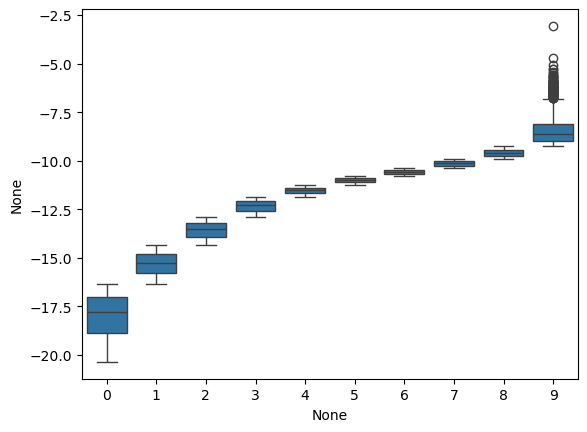

In [10]:
seaborn.boxplot(x=pd.qcut(gene_means_series, q=10, labels=False),y=gene_means_series)

In [11]:
antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/','1.9.1.8.3_Dev-Free-SecCovLaplace-NewBernoulli-NoAffine'),adata=adata,prefix='p3_',device=device)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


INFO     Generating sequential column names                                                                        


In [12]:
antipode_model.store_outputs(device=device,prefix='')

In [13]:
prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=((prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True))
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
discov_cluster_params=(np.einsum('dpm,dmg->dpg',prop_locs+prop_discov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept+prop_discov_di+np.expand_dims(pstore['discov_constitutive_de'],1)))
discov_cluster_params=torch.nn.functional.log_softmax(torch.tensor(discov_cluster_params),dim=-1).numpy()

In [14]:
true_locs=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='X_antipode',obsm=True,normalize=False)
true_discov_cluster_params=(np.einsum('dpm,dmg->dpg',true_locs[0],pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept[cluster_index,:]+prop_discov_di[:,cluster_index,:]+np.expand_dims(pstore['discov_constitutive_de'],1)))
true_discov_cluster_params=torch.nn.functional.log_softmax(torch.tensor(true_discov_cluster_params),dim=-1).numpy()

100%|██████████| 258/258 [00:01<00:00, 212.85it/s]


In [15]:
aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='spliced',normalize=True)
log_real_means=np.log(aggr_means[0]+1e-8) # #species,#cluster,#genes array

100%|██████████| 258/258 [01:47<00:00,  2.39it/s]


In [16]:
real_means=pd.DataFrame(log_real_means.mean(0),columns=adata.var.index,index=aggr_means[1]['level_2'])
real_means=real_means.loc[aggr_means[1]['level_2'],:]

In [17]:
dev_cons_means=pd.DataFrame(cluster_params,columns=adata.var.index,index=cluster_labels)
dev_cons_means=dev_cons_means.loc[aggr_means[1]['level_2'],:]

In [18]:
real_dev_mouse_means=pd.DataFrame(log_real_means[2],columns=adata.var.index,index=aggr_means[1]['level_2'])
real_dev_mouse_means=real_dev_mouse_means.loc[aggr_means[1]['level_2'],:]

In [19]:
fits=[]
for i in range(discov_cluster_params.shape[0]):
    for g in range(discov_cluster_params.shape[2]):
        x=discov_cluster_params[i,cluster_index,g]
        y=log_real_means[i,:,g]
        fits.append(scipy.stats.spearmanr(x,y).statistic)


/scratch/fast/22025122/ipykernel_3614884/2443246956.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  fits.append(scipy.stats.spearmanr(x,y).statistic)


0.6406961876230596


Text(0.5, 1.0, '')

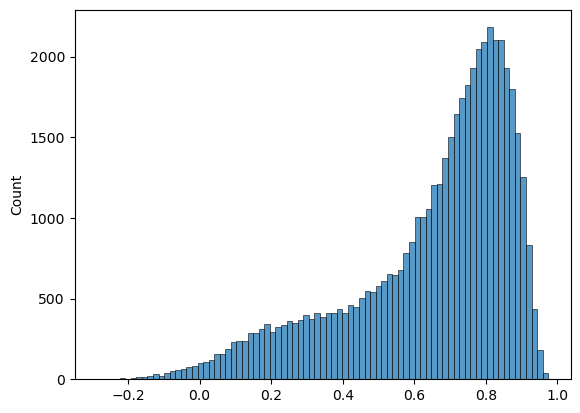

In [20]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

Text(0, 0.5, 'actual gene log mean')

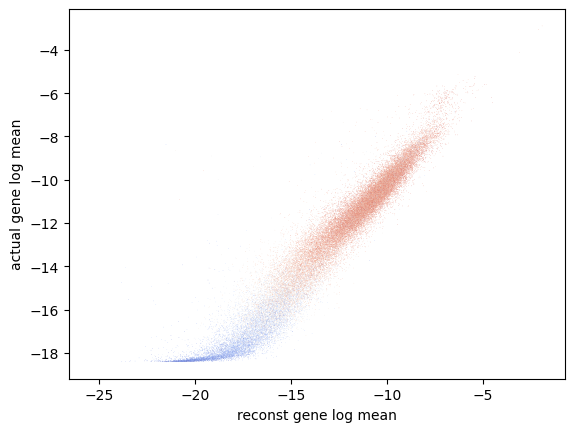

In [21]:
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(np.array(fits))
seaborn.scatterplot(x=discov_cluster_params[:,cluster_index,:].mean(1).flatten(),y=log_real_means.mean(1).flatten(),s=0.1,color=colors)
plt.xlabel('reconst gene log mean')
plt.ylabel('actual gene log mean')

In [22]:
print(cluster_index)
print(aggr_means[1]['level_2'])

Index([106, 107, 112, 119,  12, 120, 122, 128,  13, 130, 131, 132, 134, 135,
       141, 147, 149, 150, 157, 159, 161, 163, 167, 168, 169,  17, 172, 175,
       177,  18, 181,  19, 190, 194, 199, 202, 203, 208,  21, 211, 214, 215,
       219,  22, 223, 227, 237, 240, 245, 254, 257, 258, 262, 266, 267, 268,
       270, 273, 274, 279,  28, 280, 285, 287, 288, 290, 293, 296,  30,  33,
        36,  42,  47,  49,  57,  59,  61,  63,  68,   7,  70,  84,  85,  86,
        88,  94],
      dtype='int64')
['106', '107', '112', '119', '12', '120', '122', '128', '13', '130', '131', '132', '134', '135', '141', '147', '149', '150', '157', '159', '161', '163', '167', '168', '169', '17', '172', '175', '177', '18', '181', '19', '190', '194', '199', '202', '203', '208', '21', '211', '214', '215', '219', '22', '223', '227', '237', '240', '245', '254', '257', '258', '262', '266', '267', '268', '270', '273', '274', '279', '28', '280', '285', '287', '288', '290', '293', '296', '30', '33', '36', '42', '47', 

In [23]:
fits=[]
for g in (dev_cons_means.columns):
    x=dev_cons_means.loc[:,g]
    y=real_means.loc[:,g]
    fits.append(scipy.stats.stats.spearmanr(x,y).statistic)


/scratch/fast/22025122/ipykernel_3614884/391578605.py:5: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  fits.append(scipy.stats.stats.spearmanr(x,y).statistic)


0.6286984110143287


Text(0.5, 1.0, '')

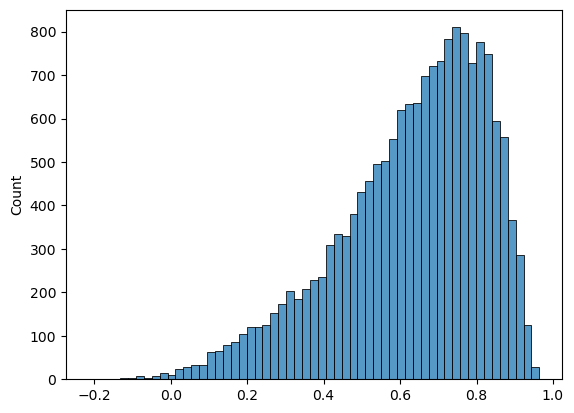

In [24]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

<Axes: xlabel='None'>

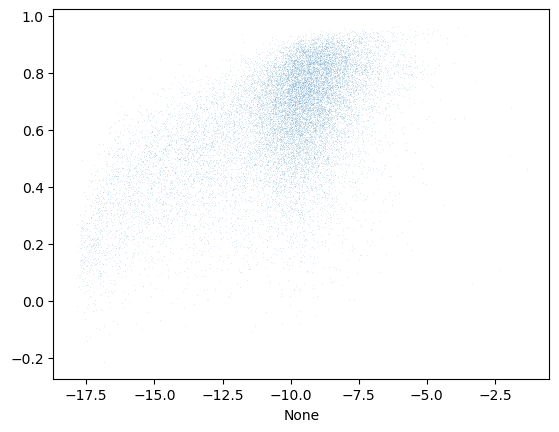

In [25]:
seaborn.scatterplot(x=real_means.max(0),y=fits,s=.1)

<Axes: xlabel='None'>

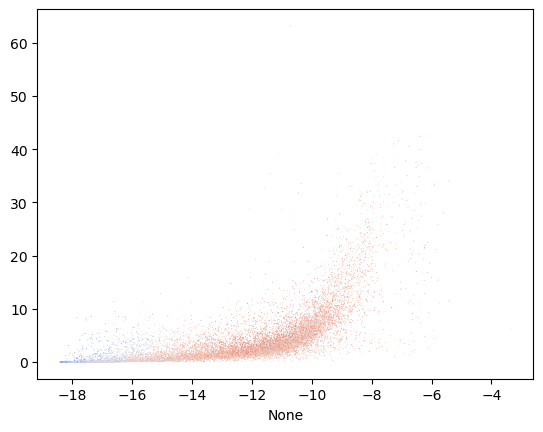

In [26]:
# Create a colormap object
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(np.array(fits))

seaborn.scatterplot(x=real_means.mean(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

<Axes: >

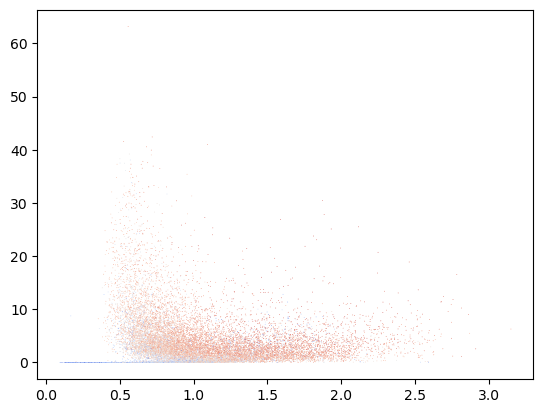

In [27]:
seaborn.scatterplot(x=log_real_means.mean(0).std(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

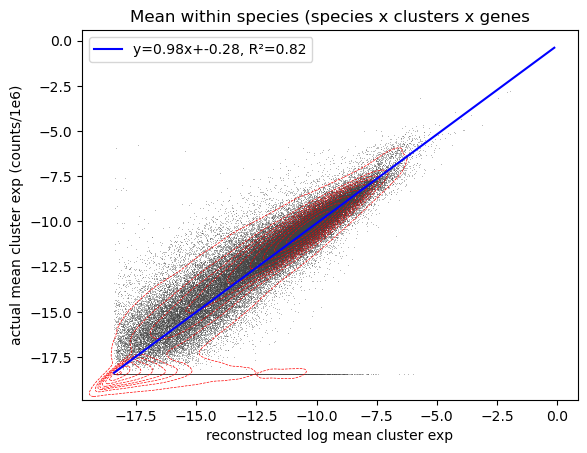

In [28]:
# Calculate the regression parameters
x=(discov_cluster_params[:,cluster_index,:]).flatten()
x=np.log(np.exp(x)+1e-8)
y=log_real_means.flatten()
#zeros=x>-6
#x=x[zeros]
#y=y[zeros]
randinds=np.random.choice(np.array(list(range(x.shape[0]))),size=100000,replace=False)


seaborn.scatterplot(x=x[randinds],y=y[randinds],s=0.2,color='black')
seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster exp')
plt.ylabel('actual mean cluster exp (counts/1e6)')


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()

In [29]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Nov 24 19:09:24 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN X (Pascal)        On  |   00000000:83:00.0 Off |                  N/A |
| 24%   36C    P8             10W /  250W |    1197MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
antipode_model.train()
antipode_model.train_phase(phase=3,max_steps=180000,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-3, one_cycle_lr=False, steps=0, batch_size=32,freeze_encoder=True,train_batch_var=True)

Training group 0:   0%|          | 0/180000 [00:00<?, ?it/s]

fix scale factor


Training group 0:   0%|          | 1/180000 [00:00<47:29:23,  1.05it/s]/scratch/fast/22025122/ipykernel_3614884/1382832878.py:303: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sum(var_index.shape) > 1:
/scratch/fast/22025122/ipykernel_3614884/1382832878.py:304: TracerWarning: Using len to get tensor shape might cause the trace to be incorrect. Recommended usage would be tensor.shape[0]. Passing a tensor of different shape might lead to errors or silently give incorrect results.
  self.plates['var_plate'] = pyro.plate('var_plate', len(var_index), dim=-1)
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:282: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We c

fix scale factor


Training group 0:   6%|▌         | 10004/180000 [08:35<2:18:41, 20.43it/s]

[Group 0, Step 10000]  Loss: 0.10015


Training group 0:   8%|▊         | 15032/180000 [12:43<2:15:11, 20.34it/s]
KeyboardInterrupt



In [31]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Nov 24 19:22:12 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN X (Pascal)        On  |   00000000:83:00.0 Off |                  N/A |
| 51%   81C    P2             68W /  250W |    3481MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

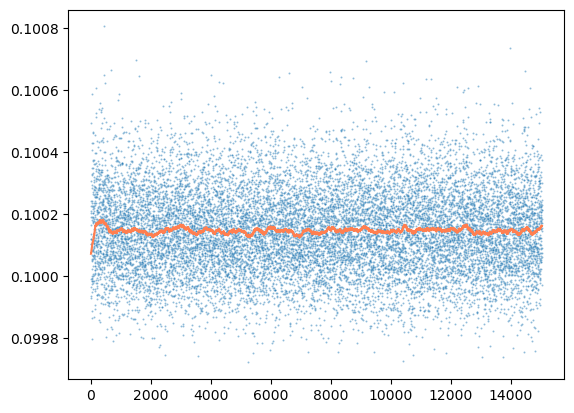

In [32]:
plot_loss(antipode_model.losses)

In [83]:
antipode_model.store_outputs(device=device,prefix='')

In [84]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Nov 24 20:00:23 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN X (Pascal)        On  |   00000000:83:00.0 Off |                  N/A |
| 46%   63C    P8             14W /  250W |    1601MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

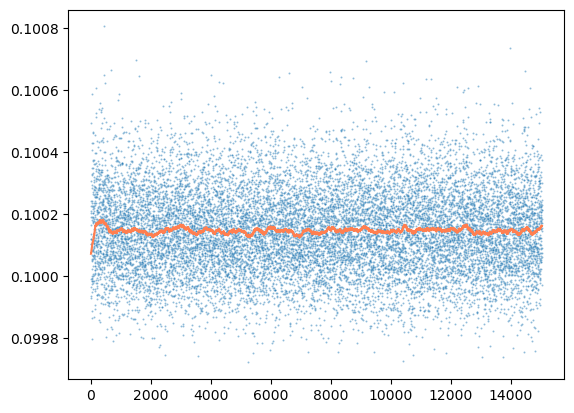

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


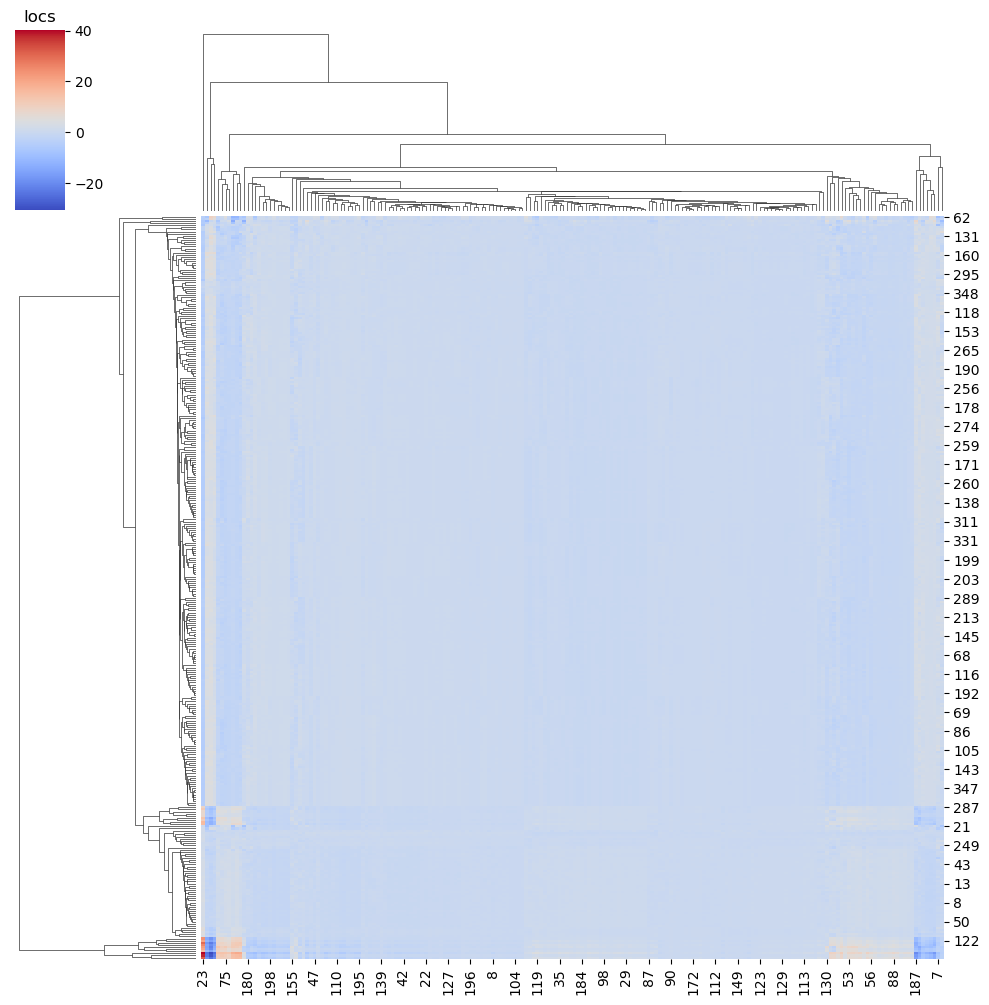

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


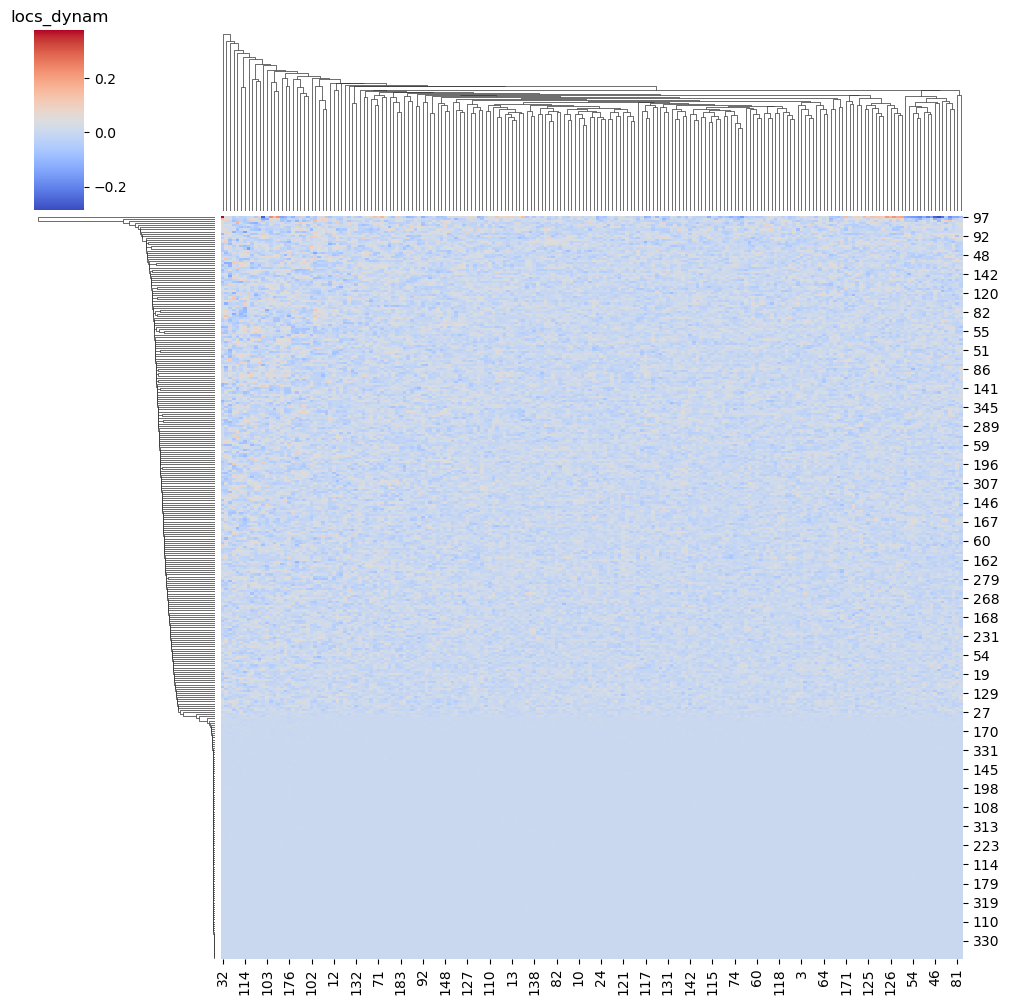

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


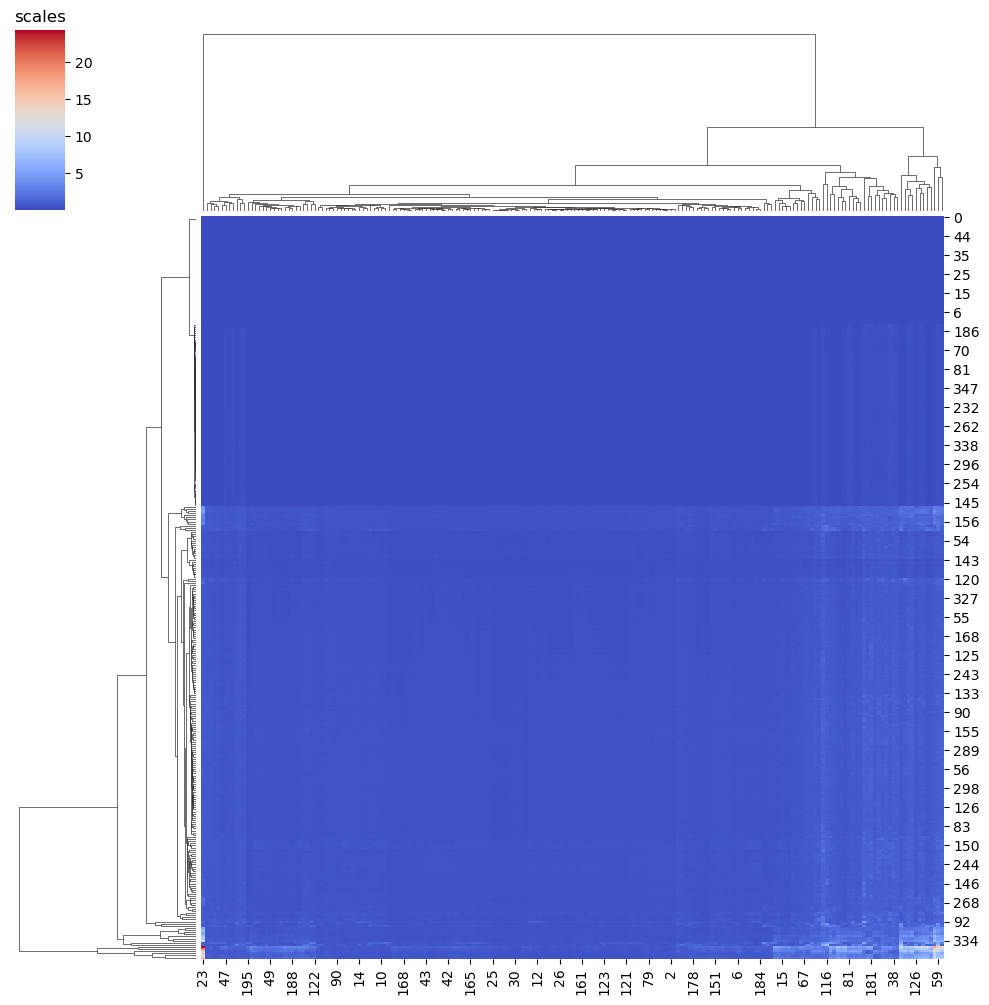

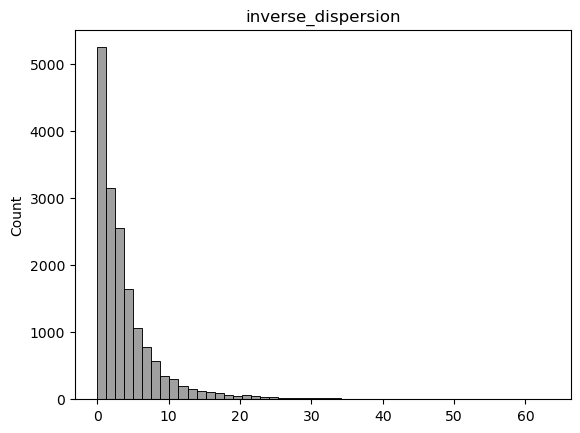

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/plotting.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_species=antipode_model.adata_manager.adata.obs.groupby(antipode_model.batch_key)['species'].value_counts().unstack().idxmax(axis=1).to_dict()


,0,1,batch_name,species
0,0.251177,-0.033035,CS12OpticVesicle_kOut,human
1,0.129600,-0.176245,CS13_anterior_midbrain_kOut,human
2,0.290576,-0.425828,CS13_central_midbrain_kOut,human
3,0.278489,-0.145076,CS13_hindbrain_kOut,human
4,0.851214,0.637977,CS13_olfactory_pacode_kOut,human
...,...,...,...,...
403,0.277843,1.119501,p0-WT2,mouse
404,-0.828269,1.018715,p0-WT3,mouse
405,-0.801489,0.953873,p0-WT4,mouse
406,0.543629,-0.014727,p07_Cortex_SRR11947654,mouse


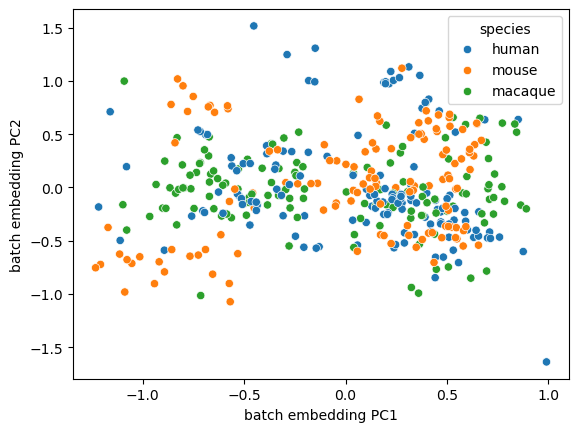

In [85]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
#plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

In [86]:
MDE_KEY = "X_antipode_MDE"
# adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
#     legend_loc='on data',palette=sc.pl.palettes.godsnot_102
# )

# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=[x for x in adata.obs.columns if 'level' in x],
#     palette=sc.pl.palettes.godsnot_102,
#     legend_loc='on data'
# )

# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
# )

# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=[x for x in adata.obs.columns if 'psi' in x],
#     cmap='coolwarm',
#     legend_loc='on data'
# )

In [87]:
# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=[x for x in adata.obs.columns if 'level' in x],
#     palette=sc.pl.palettes.godsnot_102,
#     legend_loc='on data'
# )

# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=['species','region']
# )

# sc.pl.embedding(
#     adata,
#     basis=MDE_KEY,
#     color=['phase','G2M_score','S_score','log10_n_counts'],cmap='coolwarm'
# )


<Axes: xlabel='q_score', ylabel='Count'>

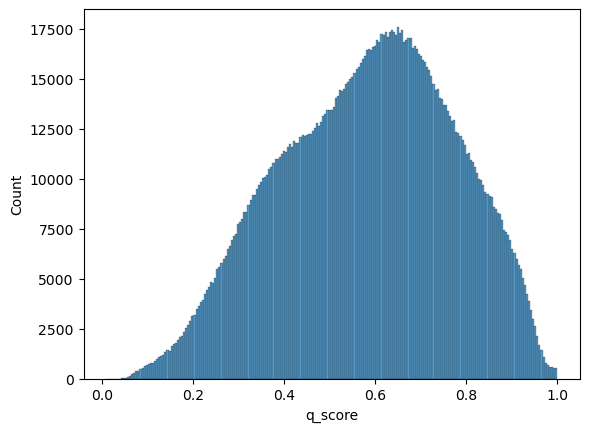

In [88]:
seaborn.histplot(adata.obs['q_score'])

In [89]:
prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=((prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True))
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
discov_cluster_params=(np.einsum('dpm,dmg->dpg',prop_locs+prop_discov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept+prop_discov_di+np.expand_dims(pstore['discov_constitutive_de'],1)))
discov_cluster_params=torch.nn.functional.log_softmax(torch.tensor(discov_cluster_params),dim=-1).numpy()

In [90]:
true_locs=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='X_antipode',obsm=True,normalize=False)
true_discov_cluster_params=(np.einsum('dpm,dmg->dpg',true_locs[0],pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept[cluster_index,:]+prop_discov_di[:,cluster_index,:]+np.expand_dims(pstore['discov_constitutive_de'],1)))
true_discov_cluster_params=torch.nn.functional.log_softmax(torch.tensor(true_discov_cluster_params),dim=-1).numpy()

100%|██████████| 258/258 [00:01<00:00, 213.38it/s]


In [91]:
aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='spliced',normalize=True)
log_real_means=np.log(aggr_means[0]+1e-8) # #species,#cluster,#genes array

100%|██████████| 258/258 [01:46<00:00,  2.42it/s]


In [92]:
real_means=pd.DataFrame(log_real_means.mean(0),columns=adata.var.index,index=aggr_means[1]['level_2'])
real_means=real_means.loc[aggr_means[1]['level_2'],:]

In [93]:
dev_cons_means=pd.DataFrame(cluster_params,columns=adata.var.index,index=cluster_labels)
dev_cons_means=dev_cons_means.loc[aggr_means[1]['level_2'],:]

In [94]:
real_dev_mouse_means=pd.DataFrame(log_real_means[2],columns=adata.var.index,index=aggr_means[1]['level_2'])
real_dev_mouse_means=real_dev_mouse_means.loc[aggr_means[1]['level_2'],:]

In [95]:
fits=[]
for i in range(discov_cluster_params.shape[0]):
    for g in range(discov_cluster_params.shape[2]):
        x=discov_cluster_params[i,cluster_index,g]
        y=log_real_means[i,:,g]
        fits.append(scipy.stats.spearmanr(x,y).statistic)


/scratch/fast/22025122/ipykernel_3614884/2443246956.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  fits.append(scipy.stats.spearmanr(x,y).statistic)


0.6411432433649411


Text(0.5, 1.0, '')

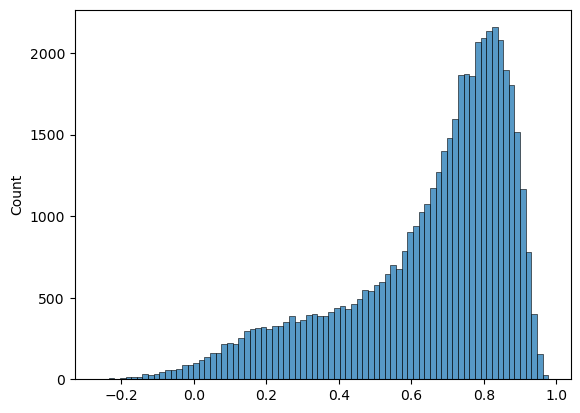

In [96]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

Text(0, 0.5, 'actual gene log mean')

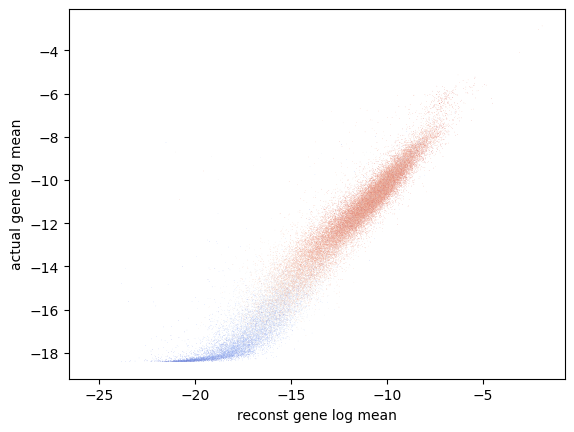

In [97]:
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(np.array(fits))
seaborn.scatterplot(x=discov_cluster_params[:,cluster_index,:].mean(1).flatten(),y=log_real_means.mean(1).flatten(),s=0.1,color=colors)
plt.xlabel('reconst gene log mean')
plt.ylabel('actual gene log mean')

In [98]:
print(cluster_index)
print(aggr_means[1]['level_2'])

Index([106, 107, 112, 119,  12, 120, 122, 128,  13, 130, 131, 132, 134, 135,
       141, 147, 149, 150, 157, 159, 161, 163, 167, 168, 169,  17, 172, 175,
       177,  18, 181,  19, 190, 194, 199, 202, 203, 208,  21, 211, 214, 215,
       219,  22, 223, 227, 237, 240, 245, 254, 257, 258, 262, 266, 267, 268,
       270, 273, 274, 279,  28, 280, 285, 287, 288, 290, 293, 296,  30,  33,
        36,  42,  47,  49,  57,  59,  61,  63,  68,   7,  70,  84,  85,  86,
        88,  94],
      dtype='int64')
['106', '107', '112', '119', '12', '120', '122', '128', '13', '130', '131', '132', '134', '135', '141', '147', '149', '150', '157', '159', '161', '163', '167', '168', '169', '17', '172', '175', '177', '18', '181', '19', '190', '194', '199', '202', '203', '208', '21', '211', '214', '215', '219', '22', '223', '227', '237', '240', '245', '254', '257', '258', '262', '266', '267', '268', '270', '273', '274', '279', '28', '280', '285', '287', '288', '290', '293', '296', '30', '33', '36', '42', '47', 

In [99]:
fits=[]
for g in (dev_cons_means.columns):
    x=dev_cons_means.loc[:,g]
    y=real_means.loc[:,g]
    fits.append(scipy.stats.stats.spearmanr(x,y).statistic)


/scratch/fast/22025122/ipykernel_3614884/391578605.py:5: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  fits.append(scipy.stats.stats.spearmanr(x,y).statistic)


0.6310912480575219


Text(0.5, 1.0, '')

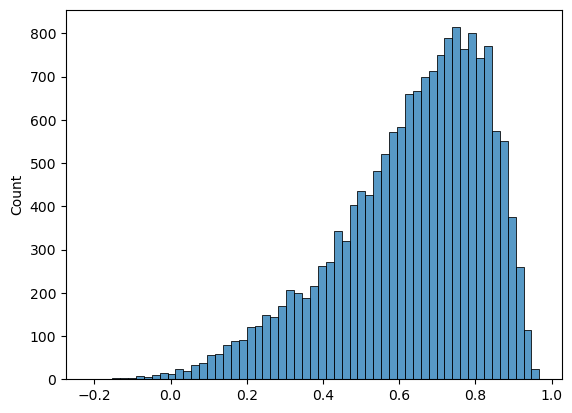

In [100]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

<Axes: xlabel='None'>

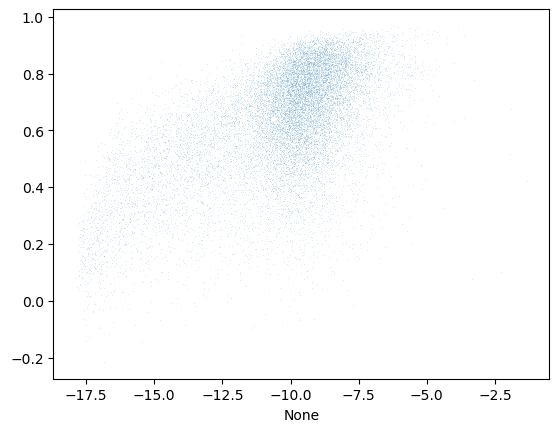

In [101]:
seaborn.scatterplot(x=real_means.max(0),y=fits,s=.1)

<Axes: xlabel='None'>

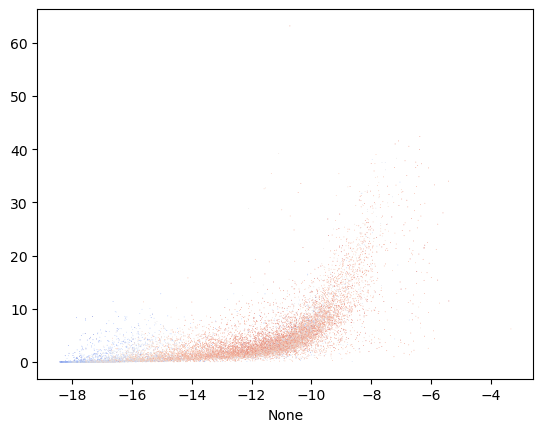

In [102]:
# Create a colormap object
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(np.array(fits))

seaborn.scatterplot(x=real_means.mean(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

<Axes: >

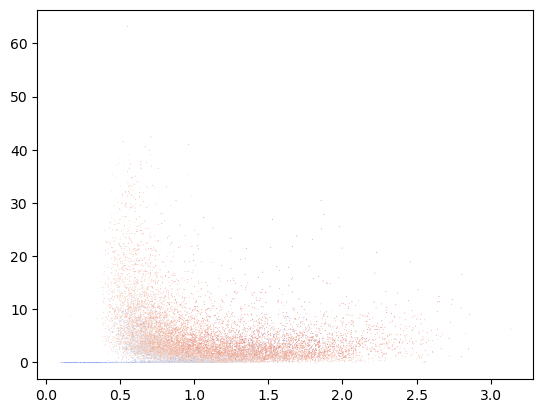

In [103]:
seaborn.scatterplot(x=log_real_means.mean(0).std(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

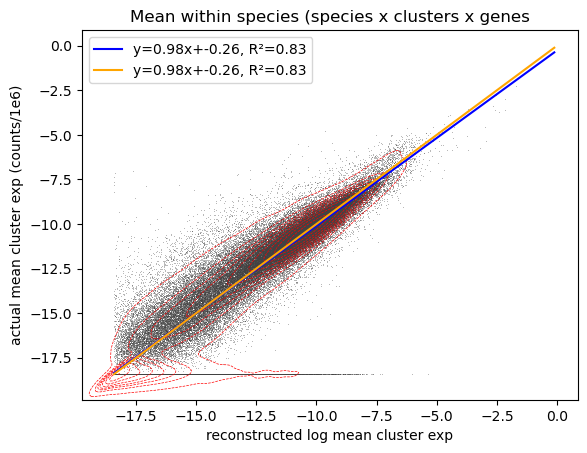

In [148]:
# Calculate the regression parameters
x=(discov_cluster_params[:,cluster_index,:]).flatten()
x=np.log(np.exp(x)+1e-8)
y=log_real_means.flatten()
#zeros=x>-6
#x=x[zeros]
#y=y[zeros]
randinds=np.random.choice(np.array(list(range(x.shape[0]))),size=100000,replace=False)


seaborn.scatterplot(x=x[randinds],y=y[randinds],s=0.2,color='black')
seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster exp')
plt.ylabel('actual mean cluster exp (counts/1e6)')


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.plot(x_values,  x_values, color='orange', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()

In [105]:
phase_sex_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],obsm=True,layer='phase_sex',normalize=False)

prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=((prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True))
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
prop_seccov_dm = np.einsum('dcp,pcm->dcm',phase_sex_means[0],np.einsum('pc,dcm->dpm',prop_taxon,pstore['seccov_dm'])[:,cluster_index,:])
discov_seccov_cluster_params=(np.einsum('dpm,dmg->dpg',prop_locs[cluster_index,:]+prop_discov_dm[:,cluster_index,:]+prop_seccov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept[cluster_index,:]+prop_discov_di[:,cluster_index,:]+np.expand_dims(pstore['discov_constitutive_de'],1)))
discov_seccov_cluster_params=torch.nn.functional.log_softmax(torch.tensor(discov_seccov_cluster_params),dim=-1).numpy()

100%|██████████| 258/258 [00:00<00:00, 496.77it/s]


In [106]:
fits=[]
for i in range(discov_cluster_params.shape[0]):
    for g in range(discov_cluster_params.shape[2]):
        x=discov_cluster_params[i,cluster_index,g]
        y=log_real_means[i,:,g]
        fits.append(scipy.stats.spearmanr(x,y).statistic)


/scratch/fast/22025122/ipykernel_3614884/2443246956.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  fits.append(scipy.stats.spearmanr(x,y).statistic)


0.6411432433649411


Text(0.5, 1.0, '')

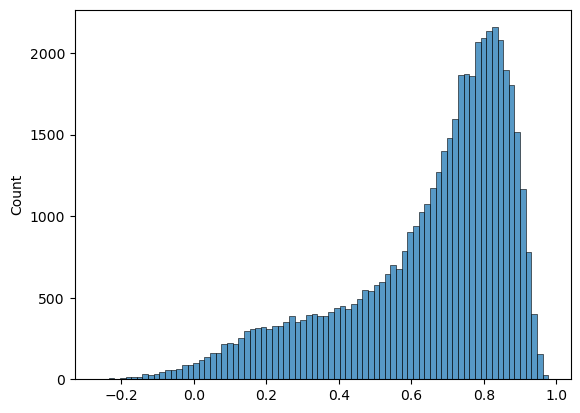

In [107]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

/scratch/fast/22025122/ipykernel_3614884/679320495.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zeromask=adata.obs.groupby('species')['level_2'].value_counts().unstack()<100


In [59]:
# zeromask=adata.obs.groupby('species')['level_2'].value_counts().unstack()<100
# discov_seccov_cluster_params[zeromask.to_numpy(),:]=0
# log_real_means[zeromask.to_numpy(),:]=0

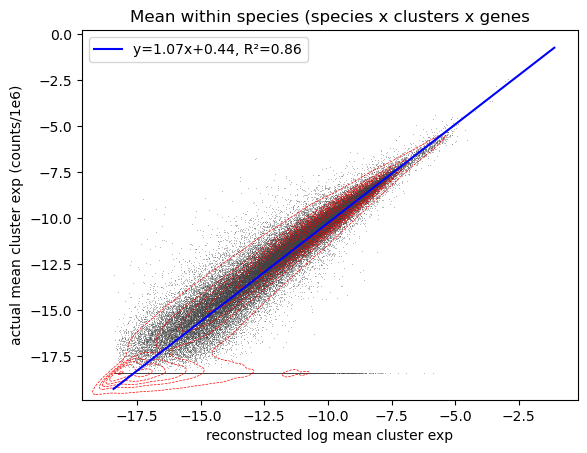

In [109]:
# Calculate the regression parameters
x=(discov_seccov_cluster_params).flatten()
x=np.log(np.exp(x)+1e-8)
y=log_real_means.flatten()
#zeros=x>-6
#x=x[zeros]
#y=y[zeros]
randinds=np.random.choice(np.array(list(range(x.shape[0]))),size=100000,replace=False)


seaborn.scatterplot(x=x[randinds],y=y[randinds],s=0.2,color='black')
seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster exp')
plt.ylabel('actual mean cluster exp (counts/1e6)')


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()

In [110]:
x=(discov_seccov_cluster_params)
x=np.log(np.exp(x)+1e-8)
y=log_real_means


<Axes: ylabel='Count'>

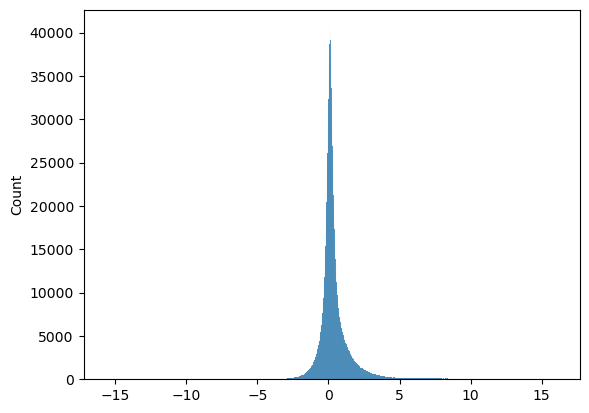

In [111]:
seaborn.histplot((x-y).flatten())

<Axes: ylabel='Count'>

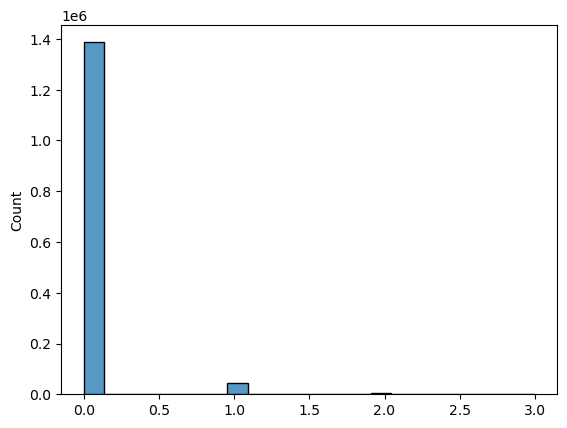

In [112]:
seaborn.histplot(((x-y)>5).sum(0).flatten())

<Axes: ylabel='Count'>

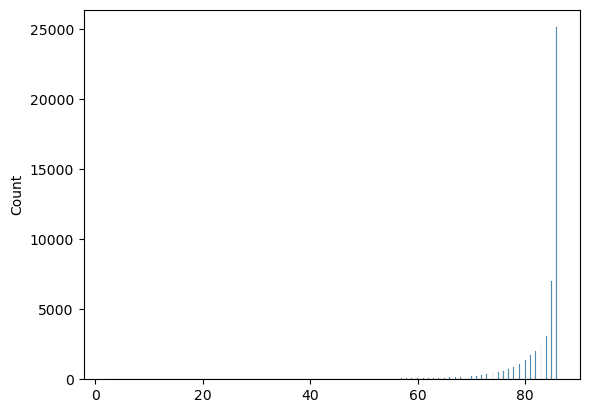

In [113]:
seaborn.histplot(((x-y)>-1).sum(1).flatten())

<Axes: ylabel='Count'>

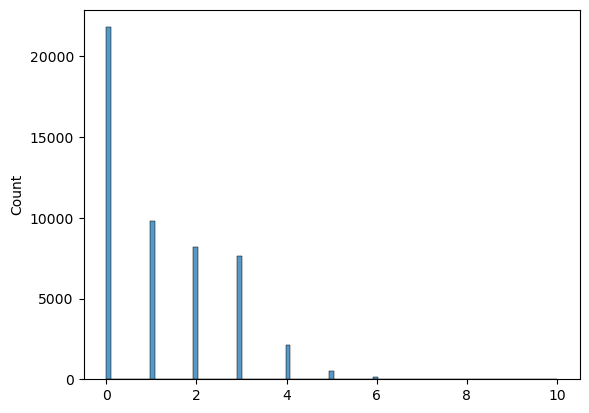

In [114]:
seaborn.histplot(((x-y)>5).sum(1).flatten())

In [115]:
(((x-y)>5).sum(1)>5).shape

(3, 16738)

<Axes: ylabel='Count'>

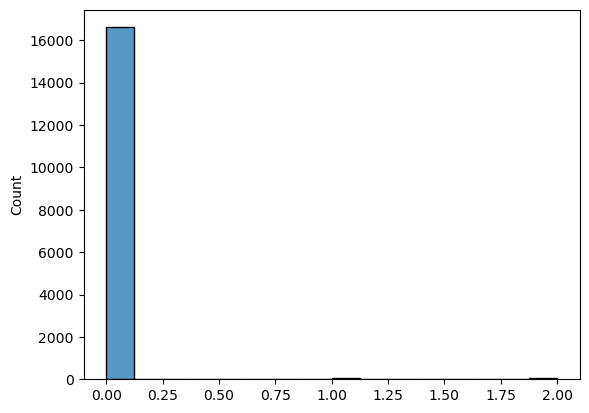

In [116]:
seaborn.histplot((((x-y)>5).sum(1)>5).argmax(0).flatten())

In [117]:
adata.var.index=adata.var['_index'].astype(str)

In [118]:
adata.strings_to_categoricals()

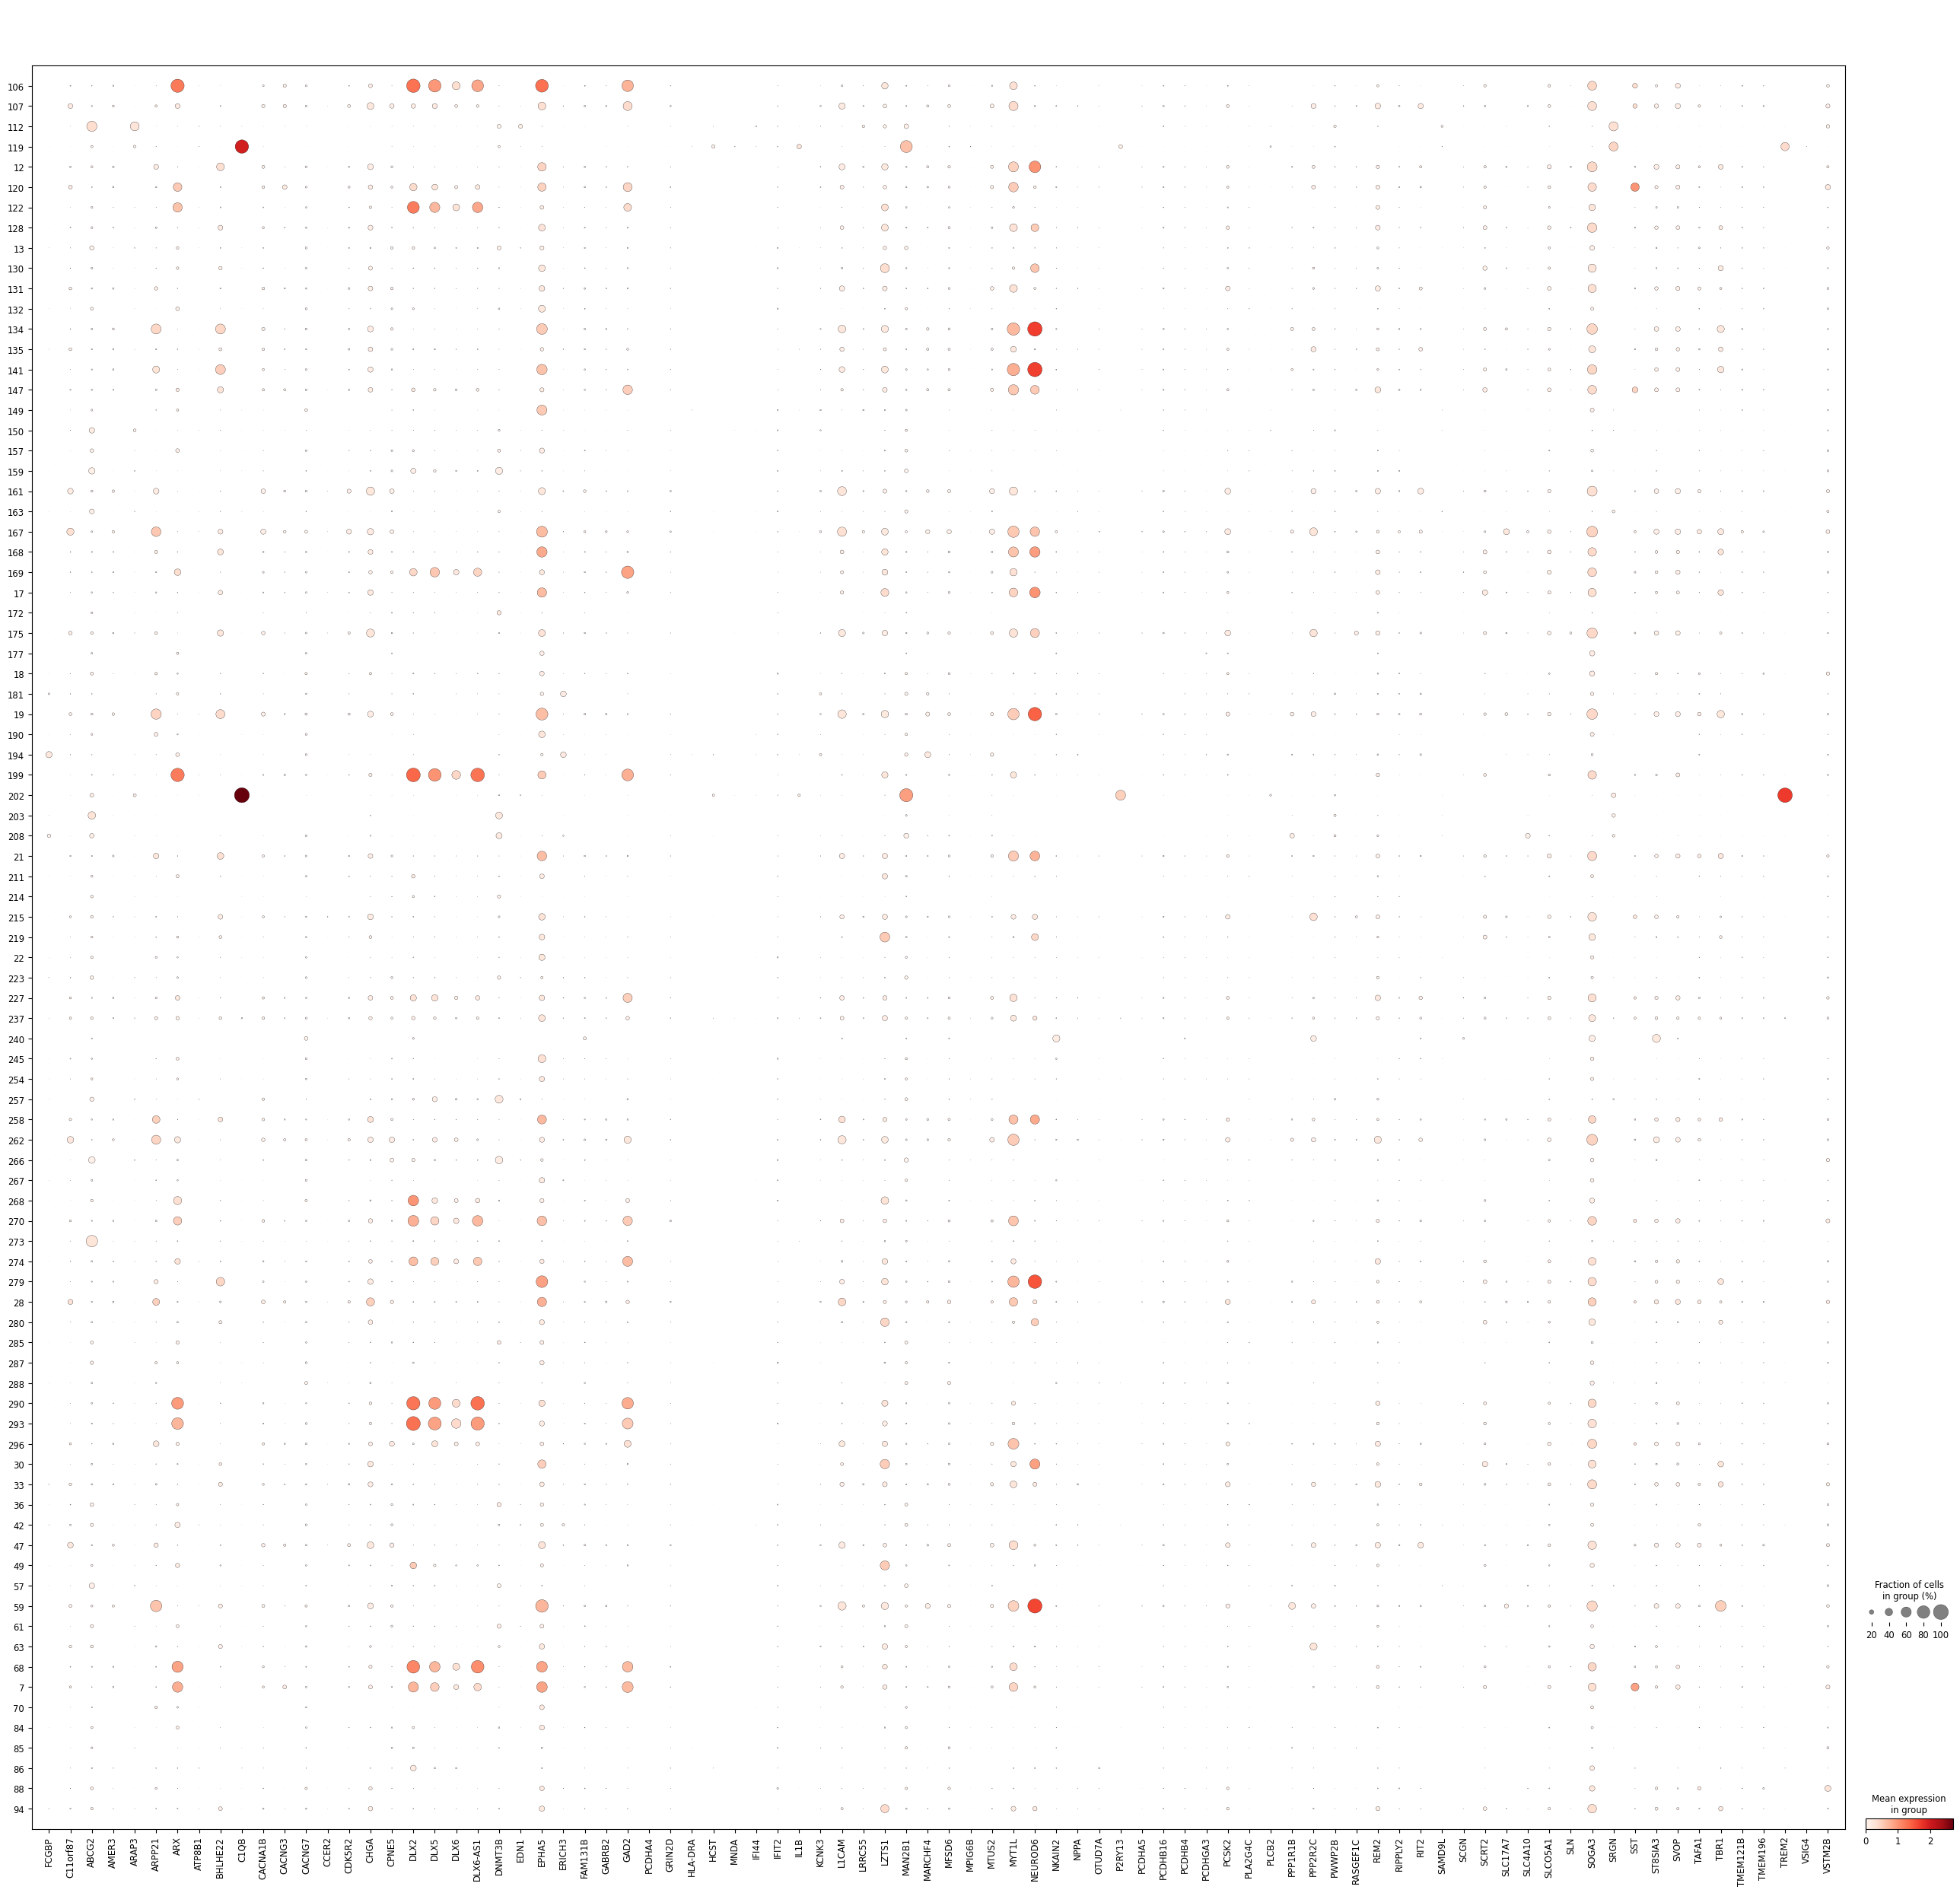

In [128]:
sc.pl.dotplot(adata[adata.obs['species']=='mouse',:],groupby='level_2',var_names=adata.var.index[np.where((((x-y)>5).sum(1)>4)[0].flatten())[0]],use_raw=False)

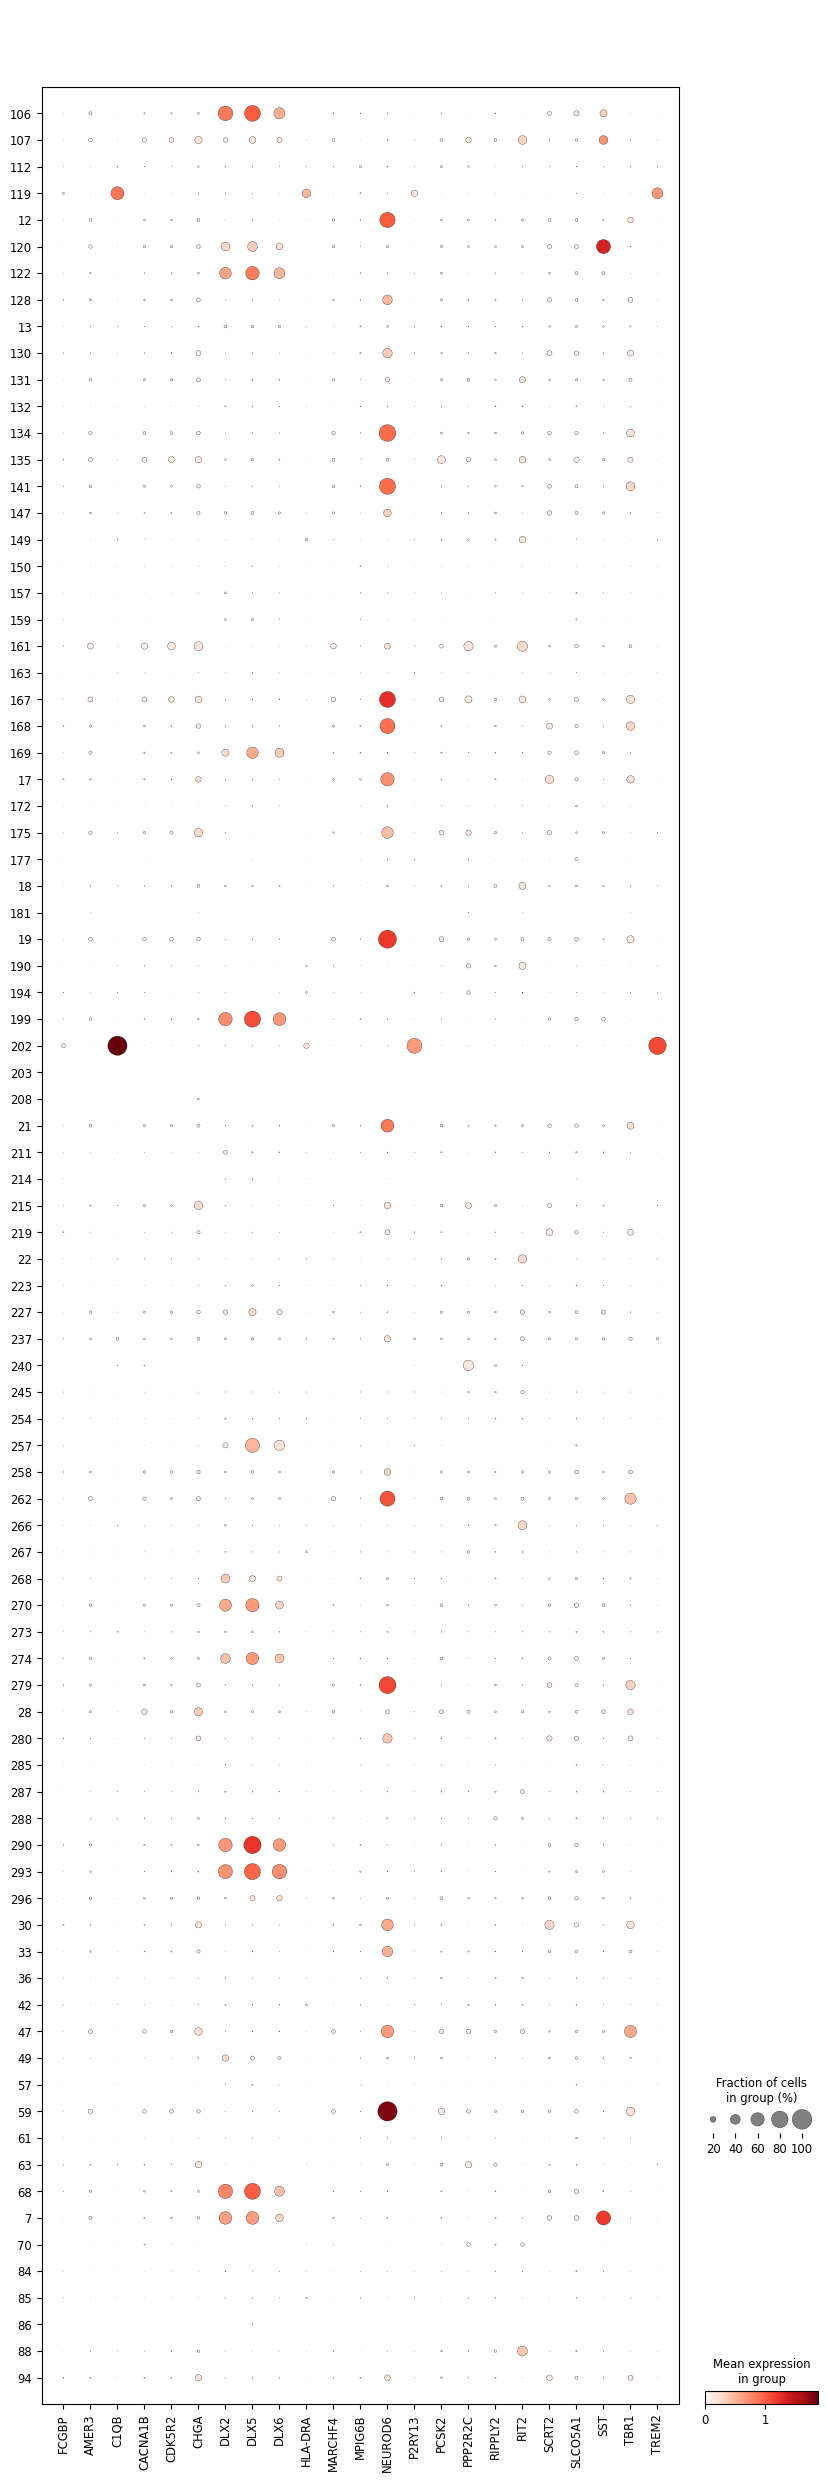

In [120]:
sc.pl.dotplot(adata[adata.obs['species']=='human',:],groupby='level_2',var_names=adata.var.index[np.where((((x-y)>5).sum(1)>4)[0].flatten())[0]],use_raw=False)

In [121]:
x[0,:,np.where(adata.var.index=='DLX2')[0]] - y[0,:,np.where(adata.var.index=='DLX2')[0]]

array([[-1.18468412e+00, -6.18934538e-01,  8.08605688e-01,
         6.41348115e-01,  9.84990686e-01, -8.10500588e-01,
        -1.38058670e+00,  4.91843172e-01, -1.19604664e+00,
         1.36049725e+00,  8.15574158e-02, -7.57669116e-01,
        -5.01094555e-03, -1.89897718e+00,  3.25701077e-01,
         6.69655307e-01,  9.07831691e-01,  9.01983370e-01,
        -1.06236327e+00,  1.74699217e+00,  8.04967596e-01,
         1.96635067e+00,  2.26116410e-01,  4.55397870e-01,
        -8.73072542e-01,  2.00133491e-01,  1.67138256e-01,
         1.49687468e+00,  5.24453141e+00, -1.74231613e-01,
         6.16728792e+00,  4.48334740e-01,  8.26320519e-01,
         2.84973030e-01, -1.25142775e+00,  1.07869386e+00,
         7.02019309e+00,  6.57031410e+00,  8.48387883e-02,
        -2.10084724e+00,  1.98205901e+00,  1.37697504e+00,
         8.28850261e-01,  1.39411447e+00,  1.12001256e-01,
        -6.91459557e-01, -5.20756646e-02,  6.52377101e+00,
        -3.04557462e-01, -1.19647197e+00, -1.17720413e-0

In [174]:
x=(discov_seccov_cluster_params)
x=np.log(np.exp(x)+1e-8)
y=log_real_means


In [175]:
diffs=x[0,:,np.where(adata.var.index=='DLX2')[0]] - y[0,:,np.where(adata.var.index=='DLX2')[0]]
diffs = ((diffs-diffs.min())/(diffs.max()-diffs.min())).flatten()

<Axes: >

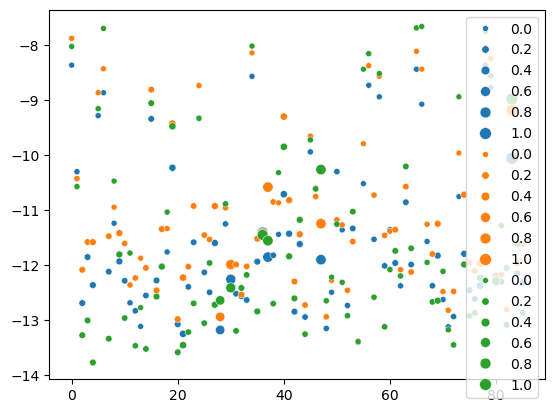

In [176]:
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[0,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[1,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[2,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)



<Axes: >

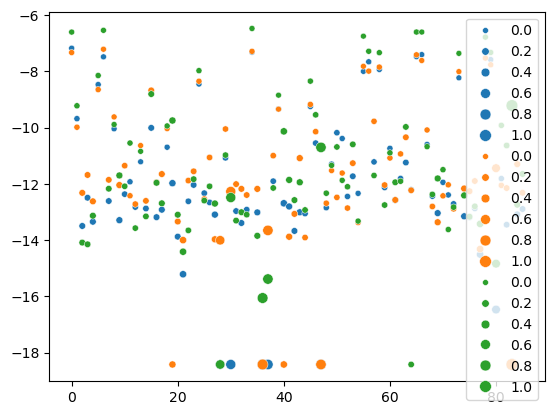

In [177]:
seaborn.scatterplot(x=list(range(x.shape[1])),y=y[0,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=y[1,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=y[2,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)


<Axes: >

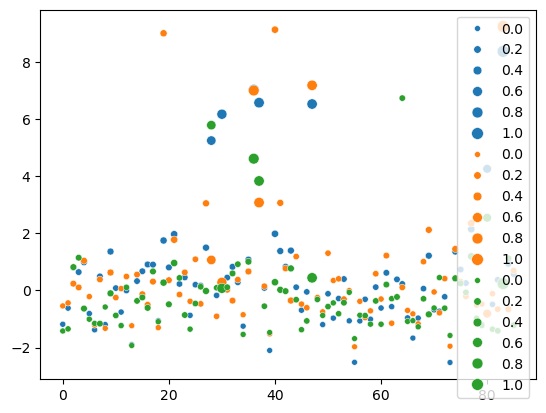

In [178]:
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[0,:,np.where(adata.var.index=='DLX2')[0]].flatten()-y[0,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[1,:,np.where(adata.var.index=='DLX2')[0]].flatten()-y[1,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)
seaborn.scatterplot(x=list(range(x.shape[1])),y=x[2,:,np.where(adata.var.index=='DLX2')[0]].flatten()-y[2,:,np.where(adata.var.index=='DLX2')[0]].flatten(),size=diffs**2)


Text(0, 0.5, 'recons - real')

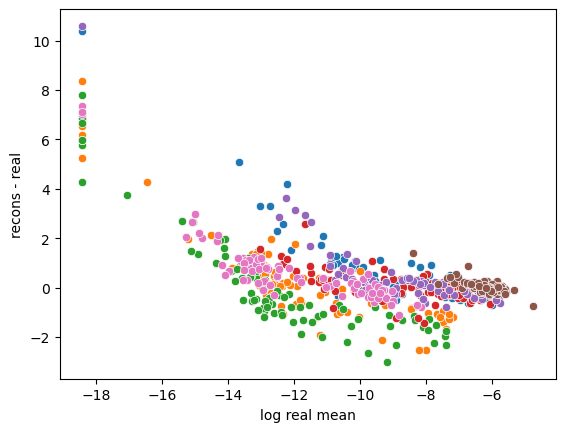

In [184]:
g = 'DCX'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'DLX2'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'DLX6'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'SOX2'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'GAP43'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'GAPDH'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
g = 'RBFOX3'
seaborn.scatterplot(y=x[0,:,np.where(adata.var.index==g)[0]].flatten()-y[0,:,np.where(adata.var.index==g)[0]].flatten(),x=y[0,:,np.where(adata.var.index==g)[0]].flatten())
plt.xlabel('log real mean')
plt.ylabel('recons - real')

/scratch/fast/22025122/ipykernel_3614884/1087338035.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seaborn.heatmap(np.log(adata.obs.groupby('species')['level_2'].value_counts().unstack()+1))


<Axes: xlabel='level_2', ylabel='species'>

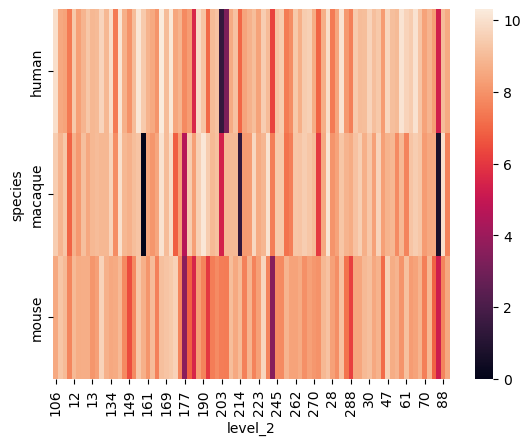

In [180]:
seaborn.heatmap(np.log(adata.obs.groupby('species')['level_2'].value_counts().unstack()+1))

In [181]:
total_count=torch.tensor([1.])
mu=torch.tensor([-8.,-7.5,-7,-5, -2, -1, 0,1, 3,5,7.5, 9])

samp=dist.NegativeBinomial(total_count=total_count,logits=mu-total_count.log()).sample([100000])

<Axes: xlabel='None', ylabel='None'>

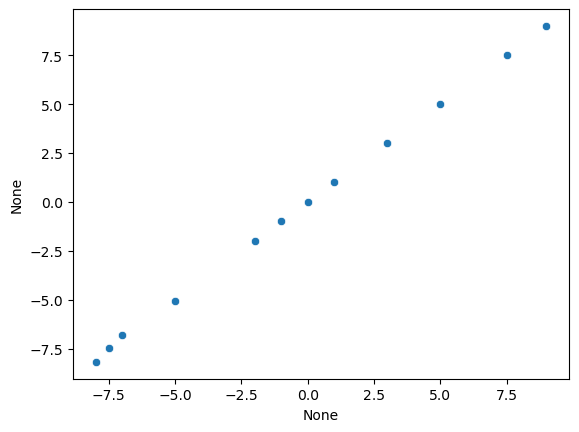

In [182]:
seaborn.scatterplot(x=mu,y=samp.mean(0).log())